In [1]:

from pathlib import Path
# 建议在包根目录 `counterfactual_spatial_cvae/` 下启动 Jupyter，使 `data/` 与 `counterfactual_spatial_cvae/` 包同级可 import
NOTEBOOK_CWD = Path.cwd()

# ---------- 按需修改 ----------
CONFIG = {
    "sample_id": "151509",
    # Visium：filtered_feature_bc_matrix 所在样本目录
    "visium_root": Path("/home_nfs/sifan.miao/STcode/data/DLPFC/DLPFC_raw"),
    # layer 注释：{sample}_truth.txt
    "truth_root": Path("/home_nfs/sifan.miao/STcode/data/DLPFC/DLPFC_raw"),
    # 模拟 h5ad 输出目录（相对于当前工作目录）
    "output_dir": NOTEBOOK_CWD / "data" / "MOSTA"
}

CONFIG["output_dir"].mkdir(parents=True, exist_ok=True)
print("CWD:", NOTEBOOK_CWD)
print("Output:", CONFIG["output_dir"])

CWD: /home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae
Output: /home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae/data/MOSTA


In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import gc# 若 Cell 5 跑完还留着
gc.collect()

0

In [4]:
 import scanpy as sc
 adata_A=sc.read_h5ad("/home_nfs/sifan.miao/1/data/MOSTA/original/E12.5_E1S1.MOSTA.h5ad")
 adata_B=sc.read_h5ad("/home_nfs/sifan.miao/1/data/MOSTA/original/E14.5_E1S1.MOSTA .h5ad")

/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


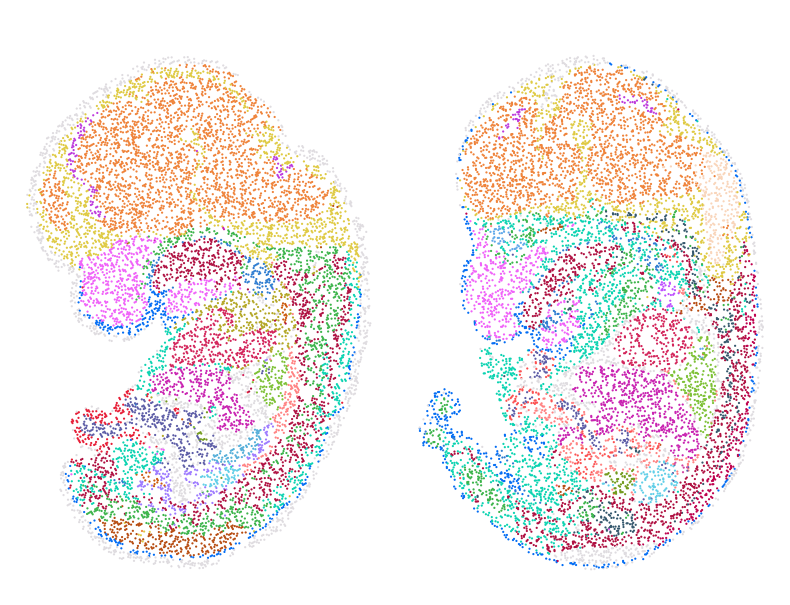

In [30]:
import scanpy as sc
import matplotlib.pyplot as plt
def process_spatial_data(adata):
    """预处理：镜像翻转 + 居中"""
    new_adata = adata.copy()
    coords = new_adata.obsm['spatial'].copy()
    
    # 1. 水平镜像翻转 (根据生物学习惯修正)
    coords[:, 1] = -coords[:, 1]
    
    # 2. 居中处理
    center = coords.mean(axis=0)
    new_adata.obsm['spatial'] = coords - center
    return new_adata

# 预处理数据
ad_ref_final = process_spatial_data(ad_ref)
ad_qry_final = process_spatial_data(ad_qry)

fig, axes = plt.subplots(1, 2, figsize=(8, 8))

for ax, adata in zip(
    axes,
    [ad_ref_final, ad_qry_final]
):
    sc.pl.embedding(
        adata,
        basis="spatial",          # 🔥 关键
        color="annotation",
        ax=ax,
        show=False,
        title=" ",
        size=10,                  # 点大小要自己调
        legend_loc=None          # 不要legend（论文更干净）
    )
    
    ax.set_aspect('equal')
    ax.set_axis_off()

plt.tight_layout()
plt.savefig("/home_nfs/sifan.miao/1/method/SpatialMETA-master/Figure4/E12.5_E14.5.svg", dpi=1200, bbox_inches='tight', facecolor='white')
plt.show()

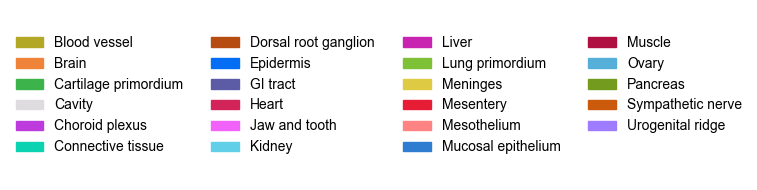

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_separate_legend(adata, color_key="annotation", ncol=4):
    """
    单独绘制图例，支持多行横向排列
    ncol: 每行显示的图例项数量
    """
    # 1. 获取类别信息和颜色映射
    # scanpy通常将颜色存储在 adata.uns['{color_key}_colors'] 中
    categories = adata.obs[color_key].cat.categories
    colors = adata.uns[f'{color_key}_colors']
    
    # 2. 创建图例句柄 (Patches)
    patches = [mpatches.Patch(color=color, label=cat) for cat, color in zip(categories, colors)]
    
    # 3. 创建空白画布绘图
    fig, ax = plt.subplots(figsize=(8, 2))
    ax.axis('off')
    
    # 4. 绘制图例
    # ncol=ncol 控制每行几个，loc='center' 居中
    ax.legend(handles=patches, 
              loc='center', 
              ncol=ncol, 
              frameon=False, 
              fontsize=10)
    
    plt.tight_layout()
    plt.savefig("/home_nfs/sifan.miao/1/method/SpatialMETA-master/Figure4/legent.svg", dpi=1200, bbox_inches='tight', facecolor='white')
    plt.show()

# 调用：假设你的类别总数是8个，ncol=4即可实现2行4列
plot_separate_legend(ad_ref_final, color_key="annotation", ncol=4)

In [5]:
import sys

PKG_ROOT = Path(".").resolve()
if str(PKG_ROOT) not in sys.path:
    sys.path.insert(0, str(PKG_ROOT))

from counterfactual_spatial_cvae import (
    CounterfactualSpatialCVAE,
    prepare_paired_anndata_with_slat,
    preset_fig3_recommended,
    recommend_batch_size,
)

ad_ref, ad_qry, ad0_raw, ad1_raw = prepare_paired_anndata_with_slat(
    adata_A,
    adata_B,
    subsample_n_obs=10000,
    copy=True,
)
# 
# STEP + recon-first + spatial=0 (see config.preset_fig3_recommended)
preset = preset_fig3_recommended()
device = "cuda:0" if __import__("torch").cuda.is_available() else "cpu"
model = CounterfactualSpatialCVAE.from_adata(
    ad0_raw, ad1_raw, model_config=preset.model, device=device
)
train_cfg = preset.training
train_cfg.n_per_batch = recommend_batch_size(ad0_raw.n_obs, ad1_raw.n_obs, cap=1024)
train_cfg.verbose = True
history = model.fit(train_cfg)

/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/libpyg.so: undefined symbol: _ZN3c109TupleTypeC1ESt6vectorINS_4Type24SingletonOrSharedTypePtrIS2_EESaIS4_EESt8optionalINS_13QualifiedNameEESt10shared_ptrINS_14FunctionSchemaEE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/libpyg.so: undefined symbol: _ZN3c109TupleTypeC1ESt6vectorINS_4Type24SingletonOrSharedTypePtrIS2_EESaIS4_EESt8optionalINS_13QualifiedNameEESt10shared_ptrINS_14FunctionSchemaEE
  warnings.warn(f"An issue occurred while importing

Calculating spatial neighbor graph ...
The graph contains 218760 edges, 10000 cells.
21.876 neighbors per cell on average.
Calculating spatial neighbor graph ...
The graph contains 219642 edges, 10000 cells.
21.9642 neighbors per cell on average.
Use pca feature to format graph


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/merge.py:1033: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_annot[label] = label_col
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/merge.py:1033: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

Choose GPU:1 as device
Running
---------- epochs: 1 ----------
---------- epochs: 2 ----------
---------- epochs: 3 ----------
---------- epochs: 4 ----------
---------- epochs: 5 ----------
---------- epochs: 6 ----------
Training model time: 1.57
common genes: 27436


/home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae/counterfactual_spatial_cvae/preprocess_slat.py:187: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata2.obs['batch'] = '1'
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
result = model.compute_drift_score(
    ad0_raw, ad1_raw,
    min_expr_logcpm=0.0,
    top_n_perturb=3000,
    n_grid=1000,
    alpha=0,
    blacklist=True,
    batch_size=1024,
)

[DriftScore] Total genes:         16117
[DriftScore] After expr+blacklist: 15106
[DriftScore] Final genes: 3000
[DriftScore] Top gene: Hbb-bs  score=0.9997  perturb=1.8199  spatial=0.0082  expr_log=4.129


In [10]:
result[:20]

,gene,score,perturb,log_perturb,spatial_spec,spatial_A,spatial_B,mean_expr_log,mean_expr_raw
0,Hbb-bs,0.999667,1.819920,1.036709,0.008202,0.0,0.016405,4.129131,3.509275
1,Hbb-y,0.999333,1.655253,0.976540,0.000022,0.0,0.000045,4.451664,3.537416
2,Hba-x,0.999000,1.493697,0.913766,0.000021,0.0,0.000042,3.167135,1.707258
3,Hbb-bt,0.998667,1.430236,0.887988,0.039009,0.0,0.078019,3.790118,3.184358
4,Hbb-bh1,0.998333,1.189123,0.783501,0.000020,0.0,0.000041,2.654212,0.806553
5,Acta1,0.998000,1.071114,0.728087,0.000024,0.0,0.000048,1.337174,0.937520
6,Hba-a2,0.997667,1.042208,0.714032,0.160346,0.0,0.320691,3.519137,2.815138
7,Lgals1,0.997333,1.040614,0.713251,0.172442,0.0,0.344883,2.422912,2.116251
8,Cd44,0.997000,1.037917,0.711928,0.000016,0.0,0.000032,3.055657,2.861531
9,Hba-a1,0.996667,0.981506,0.683857,0.178940,0.0,0.357880,4.006451,3.252065


In [ ]:
import pandas as pd

result = pd.read_csv("/home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae/RECAST_0603.csv")

In [7]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager

FONT_PATH = "/home_nfs/sifan.miao/anaconda3/envs/fonts/Arial.ttf"
fontManager.addfont(FONT_PATH)  # 必须注册，否则 rcParams 只写名字仍找不到字体
FONT_PROP = FontProperties(fname=FONT_PATH)
FONT_SANS = FONT_PROP.get_name()

plt.rcParams["font.family"] = FONT_SANS
plt.rcParams["font.sans-serif"] = [FONT_SANS]
plt.rcParams["font.serif"] = [FONT_SANS]  # 无 Times New Roman 时图例也用 Arial
plt.rcParams["axes.unicode_minus"] = False

print(f"Matplotlib font registered: {FONT_SANS} <- {FONT_PATH}")



(<Figure size 800x400 with 3 Axes>,
 array([<AxesSubplot: >, <AxesSubplot: >], dtype=object))

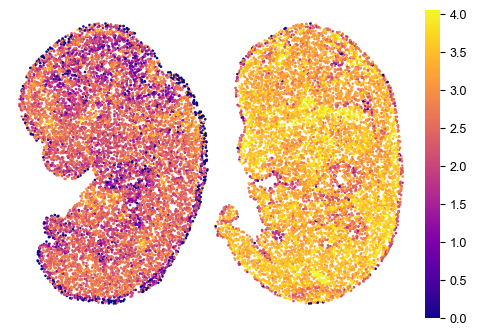

In [9]:
import numpy as np
def _get_xy(ad, basis="spatial"):
    # 优先用 obsm["spatial"]；否则尝试从 obs 里找 x/y
    if basis in ad.obsm:
        xy = np.asarray(ad.obsm[basis])
        if xy.shape[1] >= 2:
            return xy[:, 0], xy[:, 1]
    cand = [
        ("x", "y"),
        ("X", "Y"),
        ("pxl_col_in_fullres", "pxl_row_in_fullres"),
        ("imagecol", "imagerow"),
        ("array_col", "array_row"),
    ]
    for cx, cy in cand:
        if cx in ad.obs.columns and cy in ad.obs.columns:
            return ad.obs[cx].to_numpy(), ad.obs[cy].to_numpy()
    raise KeyError("找不到空间坐标：请确保 ad.obsm['spatial'] 存在，或在 ad.obs 里有 x/y 列。")

def _get_gene_vector(ad, gene, layer=None, use_raw=True):
    # 返回 (n_cells,) 的表达向量
    if use_raw and getattr(ad, "raw", None) is not None and gene in ad.raw.var_names:
        X = ad.raw[:, gene].X
    else:
        if gene not in ad.var_names:
            raise KeyError(f"{gene} 不在 ad.var_names / ad.raw.var_names 中。")
        X = ad[:, gene].X if layer is None else ad[:, gene].layers[layer]

    v = np.asarray(X).reshape(-1)
    # 兼容稀疏矩阵
    if hasattr(X, "toarray"):
        v = np.asarray(X.toarray()).reshape(-1)
    return v

def plot_spatial_gene_ref_qry(
    ad_ref,
    ad_qry,
    gene,
    basis="spatial",
    layer=None,
    use_raw=True,
    cmap="plasma",
    s=3,
    vmin=None,
    vmax=None,
    robust=True,          # True: 用 1%~99% 分位做色阶
    invert_y=True,        # 常见的切片图像坐标需要 y 轴向下
    figsize=(8, 4),
    save=None,
    dpi=1200,
):
    x1, y1 = _get_xy(ad_ref, basis=basis)
    x2, y2 = _get_xy(ad_qry, basis=basis)

    v1 = _get_gene_vector(ad_ref, gene, layer=layer, use_raw=use_raw)
    v2 = _get_gene_vector(ad_qry, gene, layer=layer, use_raw=use_raw)

    allv = np.concatenate([v1, v2])
    if vmin is None or vmax is None:
        if robust:
            lo, hi = np.nanpercentile(allv, [1, 99])
        else:
            lo, hi = np.nanmin(allv), np.nanmax(allv)
        if vmin is None: vmin = lo
        if vmax is None: vmax = hi
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
            vmin, vmax = 0.0, 1.0

    # fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.subplots_adjust(wspace=-0.5) 

    sc1 = axes[0].scatter(x1, y1, c=v1, s=s, cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0)
    axes[0].set_aspect("equal")
    axes[0].axis("off")
    if invert_y: axes[0].invert_yaxis()

    sc2 = axes[1].scatter(x2, y2, c=v2, s=s, cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0)
    axes[1].set_aspect("equal")
    axes[1].axis("off")
    if invert_y: axes[1].invert_yaxis()

    # fig.suptitle(gene, fontsize=14, y=1.02)

    # 共享色条（右侧）
    cbar = fig.colorbar(sc2, ax=axes, fraction=0.035, pad=0.02)
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False)

    if save is not None:
        # fig.savefig(save, dpi=dpi, bbox_inches="tight")
        fig.savefig(save, bbox_inches='tight', facecolor='white')
    return fig, axes

# 用法示例：
plot_spatial_gene_ref_qry(ad_ref, ad_qry, "Cd44", s=3.5, cmap="plasma",save="/home_nfs/sifan.miao/1/method/SpatialMETA-master/Figure4/Cd44.svg")

In [28]:
import anndata as ad
def compute_deg_genes(ad0_raw, ad1_raw, top_n=2000,
                      pval_thresh=0.05, lfc_thresh=0.0):
    ad0_raw.obs["condition"] = "steady"
    ad1_raw.obs["condition"] = "dss"

    print("[DEG] Concatenating...")
    adata = ad.concat([ad0_raw, ad1_raw], merge="same")
    adata.obs["condition"] = adata.obs["condition"].astype("category")

    if "log_norm" not in adata.layers:
        if "count" not in adata.layers:
            raise KeyError("Need 'count' layer")
        print("[DEG] Normalizing...")
        adata.layers["log_norm"] = adata.layers["count"].copy()
        sc.pp.normalize_total(adata, target_sum=1e4, layer="log_norm", inplace=True)
        sc.pp.log1p(adata, layer="log_norm")

    print("[DEG] Running Wilcoxon...")
    sc.tl.rank_genes_groups(
        adata,
        groupby="condition",
        method="wilcoxon",
        n_genes=adata.n_vars,   # 全部基因，后面再截断
        key_added="deg",
        layer="log_norm"
    )

    # 只取一组（steady vs dss），logFC 正负已经区分方向
    deg_df = sc.get.rank_genes_groups_df(
        adata, group="steady", key="deg"
    )

    # 过滤显著性
    deg_df = deg_df[deg_df["pvals_adj"] < pval_thresh].copy()

    # 按 |logFC| 排序，截断到 top_n
    deg_df["abs_logFC"] = deg_df["logfoldchanges"].abs()
    deg_df = deg_df[deg_df["abs_logFC"] > lfc_thresh]
    deg_df = deg_df.sort_values("abs_logFC", ascending=False).head(top_n)

    # 方向标签
    deg_df["direction"] = deg_df["logfoldchanges"].apply(
        lambda x: "steady_up" if x > 0 else "dss_up"
    )

    steady_genes = set(deg_df.loc[deg_df["direction"]=="steady_up", "names"])
    dss_genes    = set(deg_df.loc[deg_df["direction"]=="dss_up",    "names"])
    all_deg      = set(deg_df["names"])

    print(f"[DEG] Total DEGs: {len(all_deg)} "
          f"(steady_up={len(steady_genes)}, dss_up={len(dss_genes)})")

    return all_deg, steady_genes, dss_genes, deg_df, adata
all_deg, steady_genes, dss_genes, deg_df, adata= compute_deg_genes(ad_ref,ad_qry)

[DEG] Concatenating...


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[DEG] Normalizing...
[DEG] Running Wilcoxon...
[DEG] Total DEGs: 2000 (steady_up=653, dss_up=1347)


In [29]:
deg_df

,names,scores,logfoldchanges,pvals,pvals_adj,abs_logFC,direction
26903,Ibsp,-16.852068,-27.334179,1.013090e-63,4.142346e-62,27.334179,dss_up
22944,Avp,-3.012797,-24.689653,2.588520e-03,1.095290e-02,24.689653,dss_up
27321,Xist,-36.548248,-11.250472,1.901113e-292,4.172716e-290,11.250472,dss_up
120,Eif2s3y,17.930290,10.953045,6.842109e-72,3.149666e-70,10.953045,steady_up
203,Kdm5d,14.611544,10.766687,2.370833e-48,7.211328e-47,10.766687,steady_up
...,...,...,...,...,...,...,...
1126,Ttll4,5.418132,0.686580,6.022488e-08,4.298465e-07,0.686580,steady_up
24214,Stxbp2,-4.601681,-0.686097,4.190941e-06,2.519892e-05,0.686097,dss_up
374,Thoc2,11.146104,0.685982,7.481103e-29,1.421410e-27,0.685982,steady_up
25267,Angptl1,-6.517514,-0.685873,7.148211e-11,6.423791e-10,0.685873,dss_up


In [7]:
import anndata as ad
def compute_deg_genes(adata_A, adata_B, top_n=2000):
    print("[DEG] Concatenating adata...")
    adata_combined = ad.concat(
        [adata_A, adata_B], 
        label="condition",
        keys=["E15.5", "E16.5"]
    )
    adata_combined.obs["condition"] = adata_combined.obs["condition"].astype(str)
    
    # 用 log_norm 层做 DEG
    adata_combined.X = adata_combined.layers["log_norm"]
    
    print("[DEG] Running rank_genes_groups...")
    sc.tl.rank_genes_groups(
        adata_combined,
        groupby="condition",
        method="wilcoxon",
        n_genes=top_n,
        key_added="deg"
    )
    
    deg_df = sc.get.rank_genes_groups_df(
        adata_combined, 
        group="E16.5",
        key="deg"
    ).head(top_n)
    
    deg_genes = set(deg_df["names"].tolist())
    print(f"[DEG] Found {len(deg_genes)} genes")
    return deg_genes, deg_df
deg_genes, deg_df=compute_deg_genes(ad0_raw, ad1_raw)

[DEG] Concatenating adata...


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/merge.py:1033: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_annot[label] = label_col
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[DEG] Running rank_genes_groups...
[DEG] Found 2000 genes


In [ ]:
import pandas as pd
import numpy as np
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats


def diff_genes_pydeseq2(
    adata_A,
    adata_B,
    condition_names=("E12.5", "E14.5"),
    n_top=1000,
    layer=None,
    min_total_count=10,
):
    """
    用 pydeseq2 (v0.4.4) 对两个 anndata 对象做差异基因分析。
    注意：pydeseq2 是 bulk RNA-seq 工具，输入的每一行应为一个样本。
    如果是单细胞数据，建议先聚合为 pseudobulk（按样本求和），否则计算会很慢。
    """

    # ---- 1. 取 counts ----
    def _get_counts(adata):
        if layer is not None:
            X = adata.layers[layer]
        else:
            X = adata.X
        if hasattr(X, "toarray"):
            X = X.toarray()
        return pd.DataFrame(X, index=adata.obs_names, columns=adata.var_names)

    df_A = _get_counts(adata_A)
    df_B = _get_counts(adata_B)

    # ---- 2. 取共同基因并合并 ----
    common_genes = df_A.columns.intersection(df_B.columns)
    df_A = df_A[common_genes]
    df_B = df_B[common_genes]

    counts = pd.concat([df_A, df_B], axis=0)
    counts = counts.round().astype(int)

    # ---- 3. 过滤低表达基因 ----
    keep_genes = counts.sum(axis=0) >= min_total_count
    counts = counts.loc[:, keep_genes]

    # ---- 4. 构建 metadata ----
    metadata = pd.DataFrame({
        "condition": [condition_names[0]] * len(df_A) + [condition_names[1]] * len(df_B)
    }, index=counts.index)

    # pydeseq2 0.4.4 要求 metadata 的列是 category 类型
    metadata["condition"] = pd.Categorical(
        metadata["condition"],
        categories=[condition_names[0], condition_names[1]]
    )

    # ---- 5. pydeseq2 差异分析 ----
    # 0.4.4 用 design_factors，不是 design
    dds = DeseqDataSet(
        counts=counts,
        metadata=metadata,
        design_factors="condition",  # ✅ 0.4.4 的参数名
        refit_cooks=True,
    )
    dds.deseq2()

    # contrast: [variable, tested_level, reference_level]
    # 比较 condition_names[1] vs condition_names[0]
    stat_res = DeseqStats(
        dds,
        contrast=["condition", condition_names[1], condition_names[0]]
    )
    stat_res.summary()

    # ---- 6. 结果整理与排序 ----
    res = stat_res.results_df.copy()
    res = res.reset_index().rename(columns={"index": "gene"})
    res["abs_lfc"] = res["log2FoldChange"].abs()

    res_valid = res.dropna(subset=["padj"])
    res_na = res[res["padj"].isna()]
    res_sorted = res_valid.sort_values(
        by=["padj", "abs_lfc"],
        ascending=[True, False]
    )
    res_final = pd.concat([res_sorted, res_na], ignore_index=True)

    return res_final.head(n_top)


df_de = diff_genes_pydeseq2(
    adata_A=ad0_raw,
    adata_B=ad1_raw,
    condition_names=("E12.5", "E14.5"),
    n_top=1000,
)

# 提取前1000个基因名
top_genes = df_de["gene"].values[:1000]


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Fitting size factors...
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/pydeseq2/dds.py:418: RuntimeWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors()
Fitting dispersions...
... done in 19.58 seconds.

Fitting MAP dispersions...
... done in 20.98 seconds.



In [ ]:
df_de.to_csv('/home_nfs/sifan.miao/1/method/SpatialMETA-master/counterfactual_spatial_cvae/deg_df.csv', index=False)

In [9]:
import scanpy as sc
import anndata as ad
import math

def compute_deg_genes(ad0_raw, ad1_raw, top_n=2000):
    """
    ad0_raw: steady 组
    ad1_raw: dss 组
    合并后直接 Wilcoxon 比较 steady vs dss
    """
    # 1. 标注 condition
    ad0_raw.obs["condition"] = "steady"
    ad1_raw.obs["condition"] = "dss"
    
    # 2. 合并（不需要 keys，因为已经手动标注了 condition）
    print("[DEG] Concatenating steady + dss...")
    adata = ad.concat([ad0_raw, ad1_raw], merge="same")
    adata.obs["condition"] = adata.obs["condition"].astype("category")
    
    # 3. 准备表达矩阵（从 count 创建 log_norm）
    if "log_norm" not in adata.layers:
        if "count" not in adata.layers:
            raise KeyError("Need 'count' layer in adata.layers")
        
        print("[DEG] Normalizing counts...")
        adata.layers["log_norm"] = adata.layers["count"].copy()
        sc.pp.normalize_total(adata, target_sum=1e4, layer="log_norm", inplace=True)
        sc.pp.log1p(adata, layer="log_norm")
    
    # 4. Wilcoxon 秩和检验：steady vs dss
    print("[DEG] Running Wilcoxon test...")
    sc.tl.rank_genes_groups(
        adata,
        groupby="condition",
        method="wilcoxon",
        n_genes=top_n,
        key_added="deg",
        layer="log_norm"
    )
    
    # 5. 提取结果
    # steady 组高表达的基因（相对于 dss）
    steady_up = sc.get.rank_genes_groups_df(adata, group="steady", key="deg")
    # dss 组高表达的基因（相对于 steady）
    dss_up = sc.get.rank_genes_groups_df(adata, group="dss", key="deg")
    
    steady_genes = set(steady_up["names"].head(top_n))
    dss_genes = set(dss_up["names"].head(top_n))
    
    print(f"[DEG] steady-up genes: {len(steady_genes)}")
    print(f"[DEG] dss-up genes: {len(dss_genes)}")
    
    return steady_genes, dss_genes, steady_up, dss_up, adata
steady_genes, dss_genes, steady_df, dss_df, adata_combined = compute_deg_genes(ad0_raw, ad1_raw, top_n=2000)

[DEG] Concatenating steady + dss...


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[DEG] Running Wilcoxon test...
[DEG] steady-up genes: 2000
[DEG] dss-up genes: 2000


In [25]:
import pandas as pd

def get_top_diff_genes(steady_df, dss_df, top_n=2000):
    """
    合并 steady 和 dss 的 DEG 结果，按差异幅度（|logFC|）统一排序
    """
    # 给 DataFrame 添加方向标签
    steady_df = steady_df.copy()
    dss_df = dss_df.copy()
    steady_df["direction"] = "steady_up"
    dss_df["direction"] = "dss_up"
    
    # 合并
    combined = pd.concat([steady_df, dss_df], ignore_index=True)
    
    # 取绝对 logFC 作为差异幅度
    combined["abs_logFC"] = combined["logfoldchanges"].abs()
    
    # 按差异幅度排序（差异最大的在前）
    combined = combined.sort_values("abs_logFC", ascending=False)
    
    # 去重（一个基因可能在两边都出现，保留差异更大的那条）
    combined = combined.drop_duplicates(subset="names", keep="first")
    
    return combined.head(top_n)
ranked = get_top_diff_genes(steady_df, dss_df, top_n=1000)

In [26]:
ranked 

,names,scores,logfoldchanges,pvals,pvals_adj,direction,abs_logFC
2447,Ibsp,18.113523,27.466856,2.492694e-73,7.304500e-72,dss_up,27.466856
185,Kdm5d,14.623088,27.165230,2.001134e-48,3.644326e-47,steady_up,27.165230
57,Uty,21.813951,11.663662,1.710465e-105,7.532122e-104,steady_up,11.663662
2080,Xist,37.270790,11.300470,4.880397e-304,8.938336e-302,dss_up,11.300470
106,Eif2s3y,17.918385,9.930431,8.475277e-72,2.413358e-70,steady_up,9.930431
...,...,...,...,...,...,...,...
3182,Erbb2,10.531347,0.842909,6.194152e-26,6.231657e-25,dss_up,0.842909
3755,Gnal,7.839490,0.842572,4.523791e-15,2.973489e-14,dss_up,0.842572
1375,Prkd1,4.671010,0.842413,2.997224e-06,1.065423e-05,steady_up,0.842413
2302,Chmp2a,21.963644,0.842392,6.414249e-107,2.879622e-105,dss_up,0.842392


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import anndata as ad 
import numpy as np
import matplotlib.pyplot as plt

river_ranks = np.load("/home_nfs/sifan.miao/River-main/River-main/final_rank_temporal_12vs14_gpu1.npy", allow_pickle=True)
gene_list_A = result['gene'].tolist()         
gene_list_B = river_ranks.tolist() 
import anndata as ad

gene_list_C= ranked["names"].tolist()
# gene_list_C=result['gene'].tolist()     
 
# results, names = compute_classification_curve(
#     gene_list_A=gene_list_A,
#     gene_list_B=gene_list_B,
#     gene_list_C=gene_list_C,  # 新增
#     ad_ref=ad_ref,
#     ad_qry=ad_qry,
#     k_values=[5,10, 50, 100],
#     # k_values=[5,10, 50, 100],
#     method_names=['RECAST', 'RIVER', 'DEG(Wilcoxon)']  # 三个自定义名称
# )

In [19]:
import gc
import numpy as np
import anndata as ad
from scipy.sparse import vstack, issparse
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


def _stack_gene_matrix(ad_ref, ad_qry, genes, layer="log_norm"):
    """只取需要的基因，ref/qry 分别 subset 后 vstack，避免 ad.concat 全基因合并。"""
    genes = [g for g in genes if g in ad_ref.var_names and g in ad_qry.var_names]
    if len(genes) == 0:
        raise ValueError("No overlapping genes between ad_ref and ad_qry.")

    sub_ref = ad_ref[:, genes]
    sub_qry = ad_qry[:, genes]

    X_ref = sub_ref.layers[layer] if layer in sub_ref.layers else sub_ref.X
    X_qry = sub_qry.layers[layer] if layer in sub_qry.layers else sub_qry.X

    if issparse(X_ref) or issparse(X_qry):
        return vstack([X_ref, X_qry], format="csr")
    return np.vstack([np.asarray(X_ref), np.asarray(X_qry)])


def compute_classification_curve(
    gene_list_A,
    gene_list_B,
    gene_list_C,
    ad_ref,
    ad_qry,
    k_values=(20, 50, 100, 200, 500, 1000, 2000),
    cv_folds=5,
    method_names=("Method A", "Method B", "Method C"),
    layer="log_norm",
):
    results = {
        "k": [],
        "score_A": [], "score_B": [], "score_C": [],
        "std_A": [], "std_B": [], "std_C": [],
    }

    # 标签只构造一次
    y = np.array(
        ["ref"] * ad_ref.n_obs + ["qry"] * ad_qry.n_obs,
        dtype=object,
    )

    # saga / liblinear 支持 sparse；不要用 lbfgs + toarray
    clf = LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver="saga",
        n_jobs=1,
    )

    print("=" * 90)
    print("Classification Performance Curve (3 Methods Comparison)")
    print("=" * 90)
    print(f"Reference: {ad_ref.n_obs} cells, Query: {ad_qry.n_obs} cells")
    print(f"List A: {len(gene_list_A)} genes, List B: {len(gene_list_B)} genes, List C: {len(gene_list_C)} genes")
    print("-" * 90)
    header = f"{'K':<8} {method_names[0]:<25} {method_names[1]:<25} {method_names[2]:<25}"
    print(header)
    print(f"{'':8} {'Mean ± Std':<25} {'Mean ± Std':<25} {'Mean ± Std':<25}")
    print("-" * 90)

    gene_lists = (gene_list_A, gene_list_B, gene_list_C)

    for k in k_values:
        k_actual = min(k, *(len(g) for g in gene_lists))

        scores = []
        for gene_list in gene_lists:
            genes = gene_list[:k_actual]
            X = _stack_gene_matrix(ad_ref, ad_qry, genes, layer=layer)

            # n_jobs=1 避免 CV 并行时再复制大矩阵
            fold_scores = cross_val_score(clf, X, y, cv=cv_folds, n_jobs=1)
            scores.append((fold_scores.mean(), fold_scores.std()))

            del X
            gc.collect()

        (mean_A, std_A), (mean_B, std_B), (mean_C, std_C) = scores

        results["k"].append(k_actual)
        results["score_A"].append(round(mean_A, 2))
        results["score_B"].append(round(mean_B, 2))
        results["score_C"].append(round(mean_C, 2))
        results["std_A"].append(std_A)
        results["std_B"].append(std_B)
        results["std_C"].append(std_C)

        print(
            f"{k_actual:<8} {mean_A:.4f} ± {std_A:.4f}        "
            f"{mean_B:.4f} ± {std_B:.4f}        "
            f"{mean_C:.4f} ± {std_C:.4f}"
        )
        if k_actual < k:
            print(f"         (Note: max available genes = {k_actual})")

    print("=" * 90)
    return results, list(method_names)

In [21]:
results, names = compute_classification_curve(
    gene_list_A=gene_list_A,
    gene_list_B=gene_list_B,
    gene_list_C=gene_list_C,
    ad_ref=ad_qry,    # 子采样后的，不要用 adata_A
    ad_qry=ad_ref,     # 子采样后的，不要用 adata_B
    k_values=[5,10, 50, 100, 200,500,1000],
    method_names=["RECAST", "RIVER", "DEG(Wilcoxon)"],
    layer="log_norm", 
)

Classification Performance Curve (3 Methods Comparison)
Reference: 10000 cells, Query: 10000 cells
List A: 3000 genes, List B: 27436 genes, List C: 2000 genes
------------------------------------------------------------------------------------------
K        RECAST                    RIVER                     DEG(Wilcoxon)            
         Mean ± Std                Mean ± Std                Mean ± Std               
------------------------------------------------------------------------------------------
5        0.9714 ± 0.0020        0.9662 ± 0.0019        0.7038 ± 0.0052


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


10       0.9789 ± 0.0019        0.9672 ± 0.0031        0.7913 ± 0.0055


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did 

50       0.9918 ± 0.0011        0.9950 ± 0.0005        0.9395 ± 0.0012


...

200      0.9963 ± 0.0004        0.9985 ± 0.0005        0.9939 ± 0.0013


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did 

500      0.9987 ± 0.0005        0.9993 ± 0.0003        0.9953 ± 0.0011


/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did 

1000     0.9993 ± 0.0004        0.9997 ± 0.0002        0.9976 ± 0.0006


In [22]:
df = pd.DataFrame(results)
df.to_csv('classification_results.csv', index=False)
print(f"Saved CSV: classification_results.csv")
with open('method_names.txt', 'w') as f:
    f.write('\n'.join(method_names))

Saved CSV: classification_results.csv


NameError: name 'method_names' is not defined

In [13]:
import pandas as pd

# 读取 CSV
results = pd.read_csv('classification_results.csv')

In [11]:
names=method_names=["RECAST", "RIVER", "DEG(Wilcoxon)"]

In [15]:
results['score_A']=[0.97, 0.98, 1.0, 1.0, 1.0, 1.0, 1.0]

In [18]:
def plot_classification_curve_broken_v2(
    results, method_names, save_path=None, decimals=2,
    num_fontsize=15, axis_label_fontsize=15,
):
    """
    绘制分类性能对比曲线 - 截断图版本（v2）
    - 数据四舍五入保留2位小数
    - 线条不透明 (alpha=1)
    - Y轴刻度离轴线更远
    - num_fontsize: 刻度与点标注数字统一字号
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.lines as mlines
    from matplotlib.ticker import FormatStrFormatter

    # ========== 数据四舍五入 ==========
    def round_list(arr):
        return [round(float(v), decimals) for v in arr]

    plot_results = dict(results)
    for suffix in ['A', 'B', 'C']:
        for prefix in ['score', 'std']:
            key = f'{prefix}_{suffix}'
            if key in plot_results:
                plot_results[key] = round_list(plot_results[key])

    k_values = plot_results['k']
    x_pos = np.arange(len(k_values))
    colors = ['#FF8C00', '#699ECA', '#F898CB']
    markers = ['o', 's', '^']
    suffixes = ['A', 'B', 'C']

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, sharex=True, figsize=(9, 5),
        gridspec_kw={'height_ratios': [4, 1]}
    )
    fig.patch.set_facecolor('white')
    plt.subplots_adjust(hspace=0.1)

    for ax in [ax_top, ax_bot]:
        ax.set_facecolor('white')
        for idx, suffix in enumerate(suffixes):
            score_key = f'score_{suffix}'
            std_key = f'std_{suffix}'
            if score_key not in plot_results:
                continue

            current_zorder = 5 if suffix == 'A' else 3

            ax.errorbar(
                x_pos,
                plot_results[score_key],
                yerr=plot_results.get(std_key, None),
                fmt=f'{markers[idx]}-',
                color=colors[idx],
                alpha=1.0,                          # 透明度改为 1
                linewidth=2.0,
                markersize=10,
                markerfacecolor=colors[idx],
                markeredgecolor='white',
                markeredgewidth=0.8,
                capsize=4,
                elinewidth=1.5,
                zorder=current_zorder,
            )

        ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        for x in x_pos:
            ax.axvline(x=x, color='#EEEEEE', linewidth=0.6, linestyle='-', zorder=0)

    ax_top.set_ylim(0.58, 1.05)
    ax_bot.set_ylim(0, 0.1)

    ax_top.spines['bottom'].set_visible(False)
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)
    ax_bot.spines['top'].set_visible(False)
    ax_bot.spines['right'].set_visible(False)

    for ax in [ax_top, ax_bot]:
        ax.spines['left'].set_color('#BBBBBB')
        ax.spines['left'].set_linewidth(0.8)
    ax_bot.spines['bottom'].set_color('#BBBBBB')
    ax_bot.spines['bottom'].set_linewidth(0.8)

    ax_top.tick_params(labeltop=False, bottom=False)
    ax_bot.set_xticks(x_pos)
    ax_bot.set_xticks(x_pos)
    ax_bot.set_xticklabels([str(k) for k in k_values], color='#222222')
    ax_bot.set_xlabel('K', fontsize=axis_label_fontsize, color='#222222', labelpad=6)

    y_formatter = FormatStrFormatter(f'%.{decimals}f')
    for ax in [ax_top, ax_bot]:
        ax.yaxis.set_major_formatter(y_formatter)
        ax.tick_params(axis='y', labelsize=num_fontsize, colors='#444444', pad=10)
    ax_bot.tick_params(axis='x', labelsize=num_fontsize, colors='#222222')

    fig.text(
        -0.01, 0.55, 'Classification Accuracy',
        va='center', rotation='vertical',
        fontsize=axis_label_fontsize, color='#222222'
    )

    for i, score in enumerate(plot_results['score_A']):
        ax_top.annotate(
            f'{score:.{decimals}f}',
            (i, score),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=num_fontsize,
            color=colors[0],
            zorder=10,
        )

    # 断点斜线
    d = .015
    kwargs = dict(transform=ax_top.transAxes, color='#BBBBBB', clip_on=False, linewidth=0.8)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    kwargs.update(transform=ax_bot.transAxes)
    ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)

    # 图例
    handles = []
    for idx in range(len(method_names)):
        h = mlines.Line2D(
            [], [],
            color=colors[idx],
            marker=markers[idx],
            markersize=8,
            markerfacecolor=colors[idx],
            markeredgecolor='white',
            markeredgewidth=0.6,
            linewidth=2.0,
            linestyle='-',
            alpha=1.0,
            label=method_names[idx],
        )
        handles.append(h)

    legend = ax_bot.legend(
        handles=handles,
        loc='lower left',
        frameon=True,
        facecolor='white',
        edgecolor='#CCCCCC',
        fontsize=13,
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1200, bbox_inches='tight', facecolor='white')
    plt.show()

def plot_classification_curve_single(results, method_names, save_path=None):
    """
    绘制分类性能对比曲线 - 标准单坐标轴版本
    保留：透明度差异、橙色置顶、Times New Roman字体、简约边框风格
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.lines as mlines

    k_values = results['k']
    x_pos = np.arange(len(k_values))
    colors = ['#FF8C00', '#699ECA', '#F898CB'] # A:橙色, B:蓝色, C:粉色
    markers = ['o', 's', '^']
    suffixes = ['A', 'B', 'C']
    alphas = [1.0, 1.0, 1.0] # 橙色不透明，其余略微透明

    # 创建单个坐标轴
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # 绘制曲线
    for idx, suffix in enumerate(suffixes):
        score_key = f'score_{suffix}'
        std_key = f'std_{suffix}'
        if score_key not in results: continue

        # 橙色线 (A) zorder 置顶
        current_zorder = 5 if suffix == 'A' else 3

        ax.errorbar(x_pos, results[score_key], yerr=results.get(std_key, None),
                    fmt=f'{markers[idx]}-', 
                    color=colors[idx], 
                    alpha=alphas[idx],
                    linewidth=2.0, 
                    markersize=8,
                    markerfacecolor=colors[idx], 
                    markeredgecolor='white', 
                    markeredgewidth=0.8,
                    capsize=4, 
                    elinewidth=1.5, 
                    zorder=current_zorder)

        # 仅为 Method A 显示数值标签
        if suffix == 'A':
            for i, score in enumerate(results['score_A']):
                ax.annotate(f'{score:.3f}', (i, score), textcoords="offset points",
                            xytext=(0, 10), ha='center', fontsize=8, 
                            color=colors[0], fontweight='bold', zorder=10)

    # ---------- 坐标轴与网格设置 ----------
    # 设置 X 轴
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(k) for k in k_values], fontsize=10, color='#222222')
    ax.set_xlabel('K', fontsize=11, color='#222222', labelpad=6)
    
    # 设置 Y 轴
    ax.set_ylabel('Classification Accuracy', fontsize=11, color='#222222', labelpad=6)
    ax.yaxis.set_tick_params(labelsize=9, colors='#444444')
    ax.xaxis.set_tick_params(colors='#444444')

    # 网格线样式
    ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
    for x in x_pos:
        ax.axvline(x=x, color='#EEEEEE', linewidth=0.6, linestyle='-', zorder=0)
    ax.set_axisbelow(True)

    # 边框设置
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#BBBBBB')
        ax.spines[sp].set_linewidth(0.8)

    # ---------- 图例设置 ----------
    handles = []
    for idx in range(len(method_names)):
        h = mlines.Line2D([], [], 
                          color=colors[idx], 
                          marker=markers[idx], 
                          markersize=8,
                          markerfacecolor=colors[idx], 
                          markeredgecolor='white',
                          markeredgewidth=0.6,
                          linewidth=2.0,
                          linestyle='-',
                          alpha=alphas[idx],
                          label=method_names[idx])
        handles.append(h)
    legend = ax.legend(handles=handles, loc='lower right', 
                       frameon=True, facecolor='white', 
                       edgecolor='#CCCCCC', fontsize=9)
    for text in legend.get_texts():
        text.set_fontproperties(FONT_PROP)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=1200, bbox_inches='tight', facecolor='white')
    plt.show()

# 调用
# plot_classification_curve_single(results, names)
# 调用示例
plot_classification_curve_broken_v2(results, names, save_path="classification_Fig4.svg")


NameError: name 'results' is not defined

In [10]:
import squidpy as sq
sq.gr.spatial_neighbors(ad_ref, coord_type="generic", n_neighs=6)
sq.gr.spatial_autocorr(ad_ref, mode="moran", n_jobs=4)
sq.gr.spatial_neighbors(ad_qry, coord_type="generic", n_neighs=6)
sq.gr.spatial_autocorr(ad_qry, mode="moran", n_jobs=4)



#E15.5
sq.gr.spatial_neighbors(ad0_raw, coord_type="generic", n_neighs=6)
sq.gr.spatial_autocorr(ad0_raw, mode="moran", n_jobs=4)
sq.gr.spatial_neighbors(ad1_raw, coord_type="generic", n_neighs=6)
sq.gr.spatial_autocorr(ad1_raw, mode="moran", n_jobs=4)

/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 2231 variables were constant, will return nan for these.
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 2725 variables were constant, will return nan for these.
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 3 variables were constant, will return nan for these.
  warnings.warn(
/home_nfs/sifan.miao/anaconda3/envs/scSLAT/lib/python3.8/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 3 variables were constant, will return nan for these.
  warnings.warn(


In [26]:
river_ranks

array(['Hbb-y', 'Hbb-bs', 'Gm42418', ..., 'Gm45720', 'Gm45682',
       'Olfr1133'], dtype=object)

Top-K Average Moran's I Analysis
Gene list length: 3000
Data A: 10000 cells x 27810 genes
Data B: 10000 cells x 28463 genes
------------------------------------------------------------
K        N_genes    Avg_MoranI_A    Avg_MoranI_B    Combined       
------------------------------------------------------------
5        5                 0.6064          0.4050          0.5057
10       10                0.5635          0.4637          0.5136
50       50                0.4575          0.4402          0.4488
100      100               0.3748          0.3689          0.3719
200      200               0.2999          0.2870          0.2935
300      300               0.2670          0.2531          0.2600
400      400               0.2452          0.2292          0.2372
500      500               0.2292          0.2111          0.2202
1000     1000              0.1855          0.1641          0.1748
Top-K Average Moran's I Analysis
Gene list length: 27436
Data A: 10000 cells x 27810 genes
D

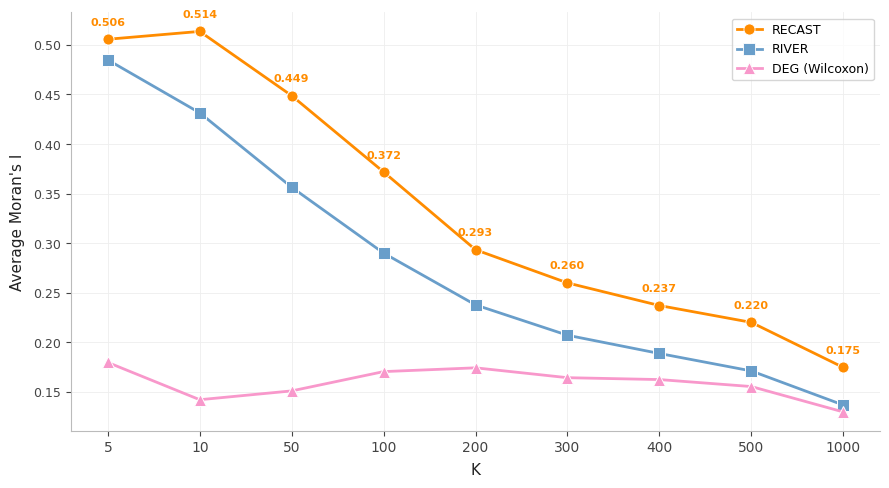

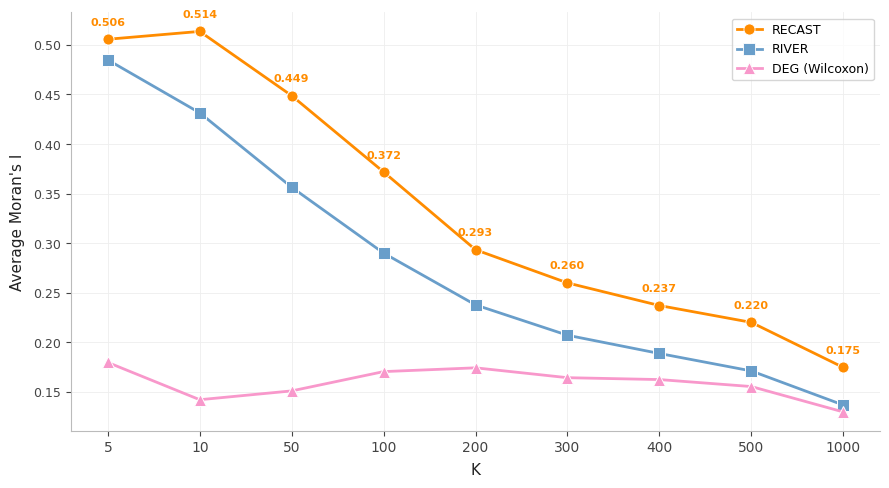

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats



def compute_topk_moranI_curve(gene_list, adata_A, adata_B, 
                               k_values=[20, 50, 100, 200, 500, 1000, 2000],
                               moran_key="moranI"):
    
    # 从uns中获取moranI DataFrame
    moran_A = adata_A.uns[moran_key].copy()
    moran_B = adata_B.uns[moran_key].copy()
    moran_B = moran_B.dropna(subset=['I'])  # 直接删除 NaN 行
    # 确保基因名是索引或列
    if 'names' in moran_A.columns:
        moran_A = moran_A.set_index('names')
    if 'names' in moran_B.columns:
        moran_B = moran_B.set_index('names')
    
    print("=" * 60)
    print("Top-K Average Moran's I Analysis")
    print("=" * 60)
    print(f"Gene list length: {len(gene_list)}")
    print(f"Data A: {adata_A.shape[0]} cells x {adata_A.shape[1]} genes")
    print(f"Data B: {adata_B.shape[0]} cells x {adata_B.shape[1]} genes")
    print("-" * 60)
    print(f"{'K':<8} {'N_genes':<10} {'Avg_MoranI_A':<15} {'Avg_MoranI_B':<15} {'Combined':<15}")
    print("-" * 60)
    
    results = {
        'k': [],
        'n_valid': [],           # 实际找到的基因数
        'avg_moran_A': [],       # 数据A的平均Moran's I
        'avg_moran_B': [],       # 数据B的平均Moran's I
        'avg_moran_combined': [], # 两个数据的平均
        'sem_A': [],             # 标准误A
        'sem_B': [],             # 标准误B
        'genes_used': []         # 实际使用的基因列表
    }
    
    for k in k_values:
        # 取Top-K基因
        topk_genes = gene_list[:min(k, len(gene_list))]
        
        # 在A中找到存在的基因
        valid_genes_A = [g for g in topk_genes if g in moran_A.index]
        moran_values_A = moran_A.loc[valid_genes_A, 'I'].values if len(valid_genes_A) > 0 else []
        
        # 在B中找到存在的基因
        valid_genes_B = [g for g in topk_genes if g in moran_B.index]
        moran_values_B = moran_B.loc[valid_genes_B, 'I'].values if len(valid_genes_B) > 0 else []
        
        # 计算统计量
        if len(moran_values_A) > 0:
            avg_A = np.mean(moran_values_A)
            sem_A = stats.sem(moran_values_A) if len(moran_values_A) > 1 else 0
        else:
            avg_A = np.nan
            sem_A = np.nan
            
        if len(moran_values_B) > 0:
            avg_B = np.mean(moran_values_B)
            sem_B = stats.sem(moran_values_B) if len(moran_values_B) > 1 else 0
        else:
            avg_B = np.nan
            sem_B = np.nan
        
        # 合并两个数据的Moran's I（取平均）
        if not np.isnan(avg_A) and not np.isnan(avg_B):
            combined = (avg_A + avg_B) / 2
        elif not np.isnan(avg_A):
            combined = avg_A
        elif not np.isnan(avg_B):
            combined = avg_B
        else:
            combined = np.nan
        
        n_valid = min(len(valid_genes_A), len(valid_genes_B))
        
        results['k'].append(k)
        results['n_valid'].append(n_valid)
        results['avg_moran_A'].append(avg_A)
        results['avg_moran_B'].append(avg_B)
        results['avg_moran_combined'].append(combined)
        results['sem_A'].append(sem_A)
        results['sem_B'].append(sem_B)
        results['genes_used'].append(list(set(valid_genes_A) & set(valid_genes_B)))
        
        print(f"{k:<8} {n_valid:<10} {avg_A:>13.4f}   {avg_B:>13.4f}   {combined:>13.4f}")
        
        if len(valid_genes_A) < k or len(valid_genes_B) < k:
            print(f"         (Warning: A={len(valid_genes_A)}, B={len(valid_genes_B)} genes found)")
    
    print("=" * 60)
    return results

def compare_multiple_gene_lists(gene_lists_dict, adata_A, adata_B, k_values=[100, 500, 1000],save_path=None):
    """
    比较多个基因列表 - 参考风格版本
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.lines as mlines
    
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # 生成均匀分布的x位置
    x_pos = np.arange(len(k_values))
    
    # 颜色方案
    colors = [
        '#FF8C00',  # 橙色 - Method A
        '#699ECA',  # 蓝色 - Method B
        '#F898CB'   # 粉色 - Method C (新增)
    ]
    
    # 标记样式
    markers = ['o', 's', '^']  # 圆形、方形、三角形
    
    # 绘制曲线
    method_names = list(gene_lists_dict.keys())
    for idx, (name, gene_list) in enumerate(gene_lists_dict.items()):
        results = compute_topk_moranI_curve(gene_list, adata_A, adata_B, k_values)
        values = results['avg_moran_combined']
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        
        ax.plot(x_pos, values,
                color=color,
                linewidth=2.0,
                linestyle='-',
                alpha=1.0,
                marker=marker,
                markersize=8,
                markerfacecolor=color,
                markeredgecolor='white',
                markeredgewidth=0.7,
                zorder=3,
                label=name)
        
        # 显示数值标签
        if idx==0:
            offset_y = 10
            for i, (x, score) in enumerate(zip(x_pos, values)):
                ax.annotate(f'{score:.3f}', (x, score), textcoords="offset points",
                            xytext=(0, offset_y), ha='center', fontsize=8, 
                            color=color, fontweight='bold')
    
    # ---------- 坐标轴设置 ----------
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(k) for k in k_values], fontsize=10, color='#222222')
    # ax.set_xticklabels([f'K={k}' for k in k_values], fontsize=10, color='#222222')
    ax.set_xlabel('K', fontsize=11, color='#222222', labelpad=6)
    ax.set_ylabel("Average Moran's I", fontsize=11, color='#222222', labelpad=6)
    ax.yaxis.set_tick_params(labelsize=9, colors='#444444')
    ax.xaxis.set_tick_params(colors='#444444')
    
    # 网格线
    ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    
    # 垂直分割线
    for x in x_pos:
        ax.axvline(x=x, color='#EEEEEE', linewidth=0.6, linestyle='-', zorder=0)
    
    # 边框设置
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#BBBBBB')
        ax.spines[sp].set_linewidth(0.8)
    
    # # 保持原范围不变
    # ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    
    # ---------- 图例 ----------
    handles = []
    for idx, name in enumerate(method_names):
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        h = mlines.Line2D([], [],
                          color=color,
                          linewidth=2.0,
                          linestyle='-',
                          alpha=1.0,
                          marker=marker,
                          markersize=8,
                          markerfacecolor=color,
                          markeredgecolor='white',
                          markeredgewidth=0.6,
                          label=name)
        handles.append(h)
    
    legend = ax.legend(handles=handles, loc='upper right', frameon=True, 
                       facecolor='white', edgecolor='#CCCCCC', fontsize=9)
    
    # # 标题
    # ax.set_title("Comparison of Different Gene Selection Methods", fontsize=12, 
    #              color='#222222', fontweight='bold', pad=10)
    if save_path:
        plt.savefig(save_path, dpi=1200, bbox_inches='tight', facecolor='white')
        print(f"\nFigure saved to: {save_path}")
    
    plt.tight_layout()
    plt.show()
    return fig


# ==================== 使用示例 ====================

# 运行分析
k_values = [5, 10, 50, 100, 200, 300,400,500, 1000]
list_A = result['gene'].tolist() 
list_B=river_ranks.tolist() 
list_C= deg_df['names'].tolist()  
gene_lists_dict={"RECAST":list_A,"RIVER":list_B,"DEG (Wilcoxon)":list_C}

compare_multiple_gene_lists(gene_lists_dict, ad_ref, ad_qry,k_values)

Top-K Average Moran's I Analysis
Gene list length: 3000
Data A: 10000 cells x 27810 genes
Data B: 10000 cells x 28463 genes
------------------------------------------------------------
K        N_genes    Avg_MoranI_A    Avg_MoranI_B    Combined       
------------------------------------------------------------
5        5                 0.6064          0.4050          0.5057
10       10                0.5635          0.4637          0.5136
50       50                0.4575          0.4402          0.4488
100      100               0.3748          0.3689          0.3719
200      200               0.2999          0.2870          0.2935
300      300               0.2670          0.2531          0.2600
400      400               0.2452          0.2292          0.2372
500      500               0.2292          0.2111          0.2202
1000     1000              0.1855          0.1641          0.1748
Top-K Average Moran's I Analysis
Gene list length: 27436
Data A: 10000 cells x 27810 genes
D

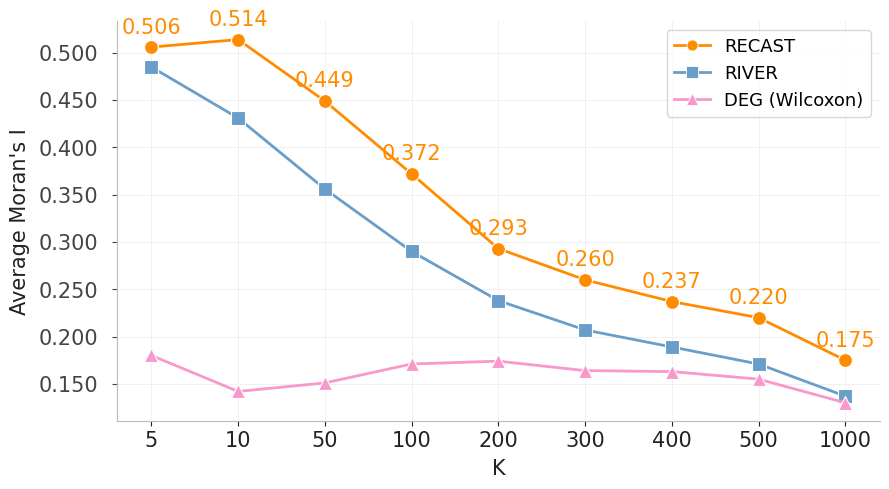

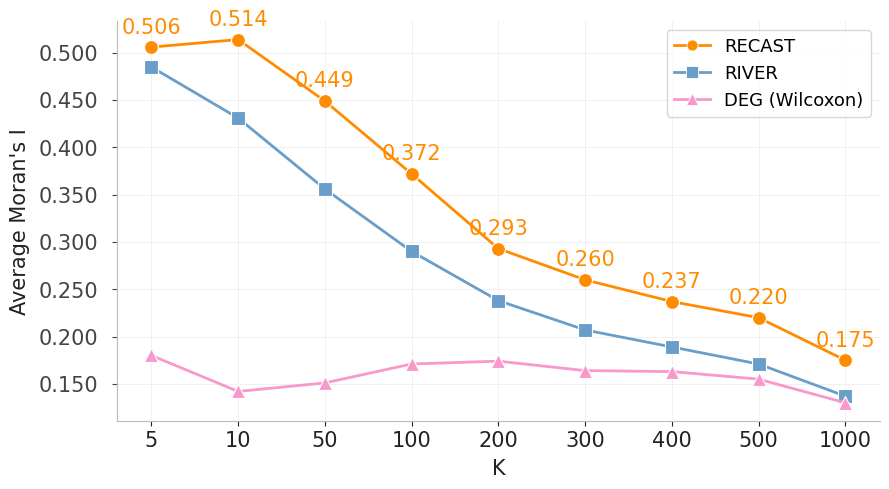

In [41]:
def compare_multiple_gene_lists_v2(
    gene_lists_dict, adata_A, adata_B, k_values=[100, 500, 1000],
    save_path=None, decimals=3,
    num_fontsize=15, axis_label_fontsize=15,
):
    """
    比较多个基因列表 - 与 plot_classification_curve_broken_v2 一致的字体/字号/坐标轴格式
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib.lines as mlines
    from matplotlib.ticker import FormatStrFormatter

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    x_pos = np.arange(len(k_values))
    colors = ['#FF8C00', '#699ECA', '#F898CB']
    markers = ['o', 's', '^']
    method_names = list(gene_lists_dict.keys())

    for idx, (name, gene_list) in enumerate(gene_lists_dict.items()):
        results = compute_topk_moranI_curve(gene_list, adata_A, adata_B, k_values)
        values = [round(float(v), decimals) for v in results['avg_moran_combined']]
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        current_zorder = 5 if idx == 0 else 3

        ax.plot(
            x_pos, values,
            color=color,
            linewidth=2.0,
            linestyle='-',
            alpha=1.0,
            marker=marker,
            markersize=10,
            markerfacecolor=color,
            markeredgecolor='white',
            markeredgewidth=0.8,
            zorder=current_zorder,
            label=name,
        )

        if idx == 0:
            for i, (x, score) in enumerate(zip(x_pos, values)):
                ax.annotate(
                    f'{score:.{decimals}f}',
                    (x, score),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha='center',
                    fontsize=num_fontsize,
                    color=color,
                    zorder=10,
                )

    ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for x in x_pos:
        ax.axvline(x=x, color='#EEEEEE', linewidth=0.6, linestyle='-', zorder=0)

    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(k) for k in k_values], color='#222222')
    ax.set_xlabel('K', fontsize=axis_label_fontsize, color='#222222', labelpad=6)

    y_formatter = FormatStrFormatter(f'%.{decimals}f')
    ax.yaxis.set_major_formatter(y_formatter)
    ax.tick_params(axis='y', labelsize=num_fontsize, colors='#444444', pad=10)
    ax.tick_params(axis='x', labelsize=num_fontsize, colors='#222222')

    ax.set_ylabel("Average Moran's I", fontsize=axis_label_fontsize, color='#222222', labelpad=6)

    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color('#BBBBBB')
        ax.spines[sp].set_linewidth(0.8)

    handles = []
    for idx, name in enumerate(method_names):
        color = colors[idx % len(colors)]
        marker = markers[idx % len(markers)]
        h = mlines.Line2D(
            [], [],
            color=color,
            marker=marker,
            markersize=8,
            markerfacecolor=color,
            markeredgecolor='white',
            markeredgewidth=0.6,
            linewidth=2.0,
            linestyle='-',
            alpha=1.0,
            label=name,
        )
        handles.append(h)

    ax.legend(
        handles=handles,
        loc='upper right',
        frameon=True,
        facecolor='white',
        edgecolor='#CCCCCC',
        fontsize=13,
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', facecolor='white')
        print(f"\nFigure saved to: {save_path}")
    plt.show()
    return fig


# 使用 v2 版本（样式与 plot_classification_curve_broken_v2 一致）
compare_multiple_gene_lists_v2(gene_lists_dict, ad_ref, ad_qry, k_values,save_path="river_vs_deg.svg")


p_spatial 0.03524540454059599
p_cond 0.45978920349707764


NameError: name 'save_path' is not defined

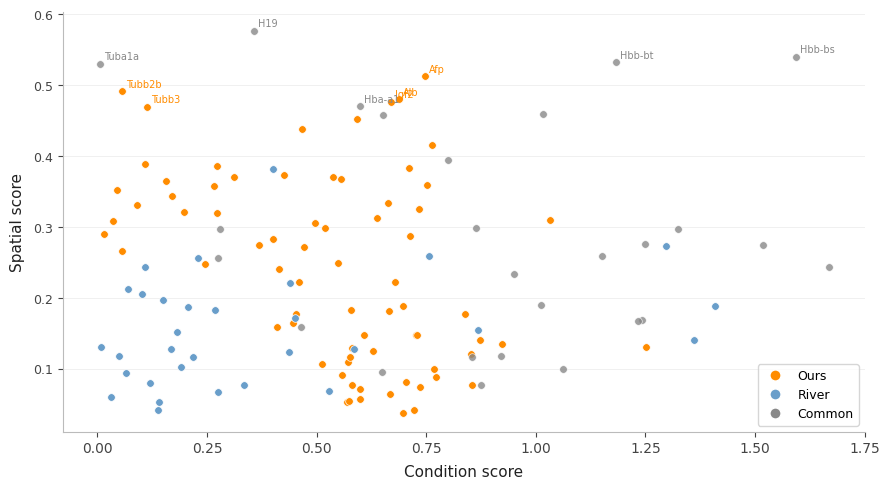

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.stats import mannwhitneyu
import matplotlib.lines as mlines
def compute_gene_scores_v2(adata_A, adata_B, gene_list,
                            annotation_key="cell_name"):
    import scipy.stats as stats

    def _get_lognorm(adata):
        x = adata.layers["log_norm"]
        # x = adata.X
        return x.toarray() if sp.issparse(x) else np.array(x)

    def _eta_squared(expr, labels, min_spots=5):
        regions = [r for r in np.unique(labels)
                   if (labels == r).sum() >= min_spots]
        if len(regions) < 2:
            return 0.0

        grand_mean = expr.mean()
        # between-group SS
        ss_between = sum(
            (labels == r).sum() * (expr[labels == r].mean() - grand_mean) ** 2
            for r in regions
        )
        # total SS
        ss_total = ((expr - grand_mean) ** 2).sum()

        return float(ss_between / (ss_total + 1e-8))   # [0, 1]

    X_A = _get_lognorm(adata_A)
    X_B = _get_lognorm(adata_B)
    gnames = list(adata_A.var_names)

    labels_A = np.array(adata_A.obs[annotation_key].astype(str))
    labels_B = np.array(adata_B.obs[annotation_key].astype(str))

    results = []
    for gene in gene_list:
        if gene not in gnames:
            continue
        gi = gnames.index(gene)
        a  = X_A[:, gi]
        b  = X_B[:, gi]

        # ── condition_score: log-space mean difference ────────
        # Cohen's d in log_norm space，scale-invariant
        pooled_std = np.sqrt((a.var() + b.var()) / 2 + 1e-8)
        cond_score = abs(a.mean() - b.mean()) / pooled_std

        # ── spatial_score: eta² averaged over both conditions ─
        # eta² = between_region_SS / total_SS ∈ [0, 1]
        eta_A = _eta_squared(a, labels_A)
        eta_B = _eta_squared(b, labels_B)
        spatial_score = (eta_A + eta_B) / 2   # 两个条件都考虑

        results.append(dict(
            gene=gene,
            condition_score=cond_score,
            spatial_score=spatial_score,
            eta_A=eta_A,
            eta_B=eta_B,
        ))

    return pd.DataFrame(results)

def plot_condition_vs_spatial(
    adata_A, adata_B,
    our_genes, comp_genes,
    annotation_key="cell_name",
    top_label_n=10,
    condition_names=("E15.5", "E16.5"),
#     save_path="/home_nfs/sifan.miao/1/data/DLPFC_diff/result/embroy_fig/",
):
    condA, condB = condition_names
    
    df_ours = compute_gene_scores_v2(adata_A, adata_B, our_genes, annotation_key)
    df_comp = compute_gene_scores_v2(adata_A, adata_B, comp_genes, annotation_key)
    df_ours["method"] = "Ours"
    df_comp["method"] = "River"
    df_all = pd.concat([df_ours, df_comp], ignore_index=True)
    
    # Wilcoxon test on spatial_score
    stat, p_spatial = mannwhitneyu(
        df_ours["spatial_score"], df_comp["spatial_score"],
        alternative="greater"
    )
    stat, p_cond = mannwhitneyu(
        df_ours["condition_score"], df_comp["condition_score"],
        alternative="two-sided"
    )
    print("p_spatial",p_spatial)
    print("p_cond",p_cond)
    
    # 颜色方案
    PAL = {"Ours": "#FF8C00", "River": "#699ECA"}
    
    fig1, ax1 = plt.subplots(figsize=(9, 5))
    fig1.patch.set_facecolor('white')
    ax1.set_facecolor('white')

    # 找出共同基因
    common_genes = set(df_ours["gene"]) & set(df_comp["gene"])

    for method, grp in df_all.groupby("method"):
        # 分离共同基因和独特基因
        common_mask = grp["gene"].isin(common_genes)
        unique_grp = grp[~common_mask]
        common_grp = grp[common_mask]
        
        # 独特基因用原色
        ax1.scatter(unique_grp["condition_score"], unique_grp["spatial_score"],
                    s=30, alpha=1, color=PAL[method],
                    label=method if len(common_genes) == 0 else None,
                    rasterized=True,
                    marker='o', edgecolors='white', linewidth=0.5)
        
        # 共同基因用灰色（只画一次，避免重复）
        if method == "Ours" and len(common_grp) > 0:
            ax1.scatter(common_grp["condition_score"], common_grp["spatial_score"],
                        s=30, alpha=0.8, color='#888888',
                        label=f"Common (n={len(common_genes)})",
                        rasterized=True,
                        marker='o', edgecolors='white', linewidth=0.5)

    # 标注top基因（包括共同基因中的top）
    top_label = df_ours.nlargest(top_label_n, "spatial_score")
    for _, row in top_label.iterrows():
        color = '#888888' if row["gene"] in common_genes else PAL["Ours"]
        ax1.annotate(row["gene"],
                    (row["condition_score"], row["spatial_score"]),
                    fontsize=7, xytext=(3, 3),
                    textcoords="offset points", alpha=1,
                    color=color)

    ax1.set_xlabel("Condition score", fontsize=11, color='#222222', labelpad=6)
    ax1.set_ylabel("Spatial score", fontsize=11, color='#222222', labelpad=6)
    ax1.yaxis.set_tick_params(labelsize=9, colors='#444444')
    ax1.xaxis.set_tick_params(colors='#444444')

    ax1.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
    ax1.set_axisbelow(True)

    for sp in ['top', 'right']:
        ax1.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax1.spines[sp].set_color('#BBBBBB')
        ax1.spines[sp].set_linewidth(0.8)

    # 图例
    handles = []
    for method in ["Ours", "River"]:
        h = mlines.Line2D([], [],
                        color=PAL[method],
                        linewidth=0,
                        marker='o',
                        markersize=8,
                        markerfacecolor=PAL[method],
                        markeredgecolor='white',
                        markeredgewidth=1,
                        label=method)
        handles.append(h)

    # 添加共同基因的图例
    if len(common_genes) > 0:
        h_common = mlines.Line2D([], [],
                                color='#888888',
                                linewidth=0,
                                marker='o',
                                markersize=8,
                                markerfacecolor='#888888',
                                markeredgecolor='white',
                                markeredgewidth=1,
                                label=f"Common")
        handles.append(h_common)

    legend = ax1.legend(handles=handles, loc='best', frameon=True,
                        facecolor='white', edgecolor='#CCCCCC', fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path.replace('.png', '_scatter.png'), dpi=300, 
                    bbox_inches='tight', facecolor='white')
    plt.show()    # ── 图1: 四象限图 (RECAST) ──
    from adjustText import adjust_text   # pip install adjustText，可选但推荐

    df_q = df_ours.copy()
    x_med = df_q["condition_score"].median()
    y_med = df_q["spatial_score"].median()

    # 象限分类
    def _quadrant(row):
        cx = row["condition_score"] >= x_med
        cy = row["spatial_score"] >= y_med
        if cx and cy:   return "Q1"   # 都高
        if (not cx) and cy: return "Q2"   # spatial高, condition低
        if (not cx) and (not cy): return "Q3"   # 都低
        return "Q4"   # condition高, spatial低

    df_q["quadrant"] = df_q.apply(_quadrant, axis=1)

    # 每个象限选典型基因：离象限“角点”最近的 top_n 个
    def _pick_representative(sub, corner_x, corner_y, n=3):
        sub = sub.copy()
        sub["dist"] = np.sqrt(
            (sub["condition_score"] - corner_x) ** 2 +
            (sub["spatial_score"] - corner_y) ** 2
        )
        return sub.nsmallest(n, "dist")

    x_min, x_max = df_q["condition_score"].min(), df_q["condition_score"].max()
    y_min, y_max = df_q["spatial_score"].min(), df_q["spatial_score"].max()
    pad_x = 0.05 * (x_max - x_min + 1e-8)
    pad_y = 0.05 * (y_max - y_min + 1e-8)

    quad_specs = {
        "Q1": (x_max + pad_x, y_max + pad_y, "Both high"),
        "Q2": (x_min - pad_x, y_max + pad_y, "Spatial high"),
        "Q3": (x_min - pad_x, y_min - pad_y, "Both low"),
        "Q4": (x_max + pad_x, y_min - pad_y, "Condition high"),
    }
    QUAD_COLOR = {"Q1": "#FFE8CC", "Q2": "#E8F4FD", "Q3": "#F0F0F0", "Q4": "#FDE8E8"}

    fig1, ax1 = plt.subplots(figsize=(8, 8))
    fig1.patch.set_facecolor("white")
    ax1.set_facecolor("white")

    # 象限背景色
    ax1.axvspan(x_med, x_max + pad_x * 2, ymin=0.5, ymax=1.0, color=QUAD_COLOR["Q1"], alpha=0.35, zorder=0)
    ax1.axvspan(x_min - pad_x * 2, x_med, ymin=0.5, ymax=1.0, color=QUAD_COLOR["Q2"], alpha=0.35, zorder=0)
    ax1.axvspan(x_min - pad_x * 2, x_med, ymin=0, ymax=0.5, color=QUAD_COLOR["Q3"], alpha=0.35, zorder=0)
    ax1.axvspan(x_med, x_max + pad_x * 2, ymin=0, ymax=0.5, color=QUAD_COLOR["Q4"], alpha=0.35, zorder=0)

    # 分界线
    ax1.axvline(x_med, color="#888888", ls="--", lw=1.2, zorder=1)
    ax1.axhline(y_med, color="#888888", ls="--", lw=1.2, zorder=1)

    # 散点（按象限上色）
    for q, sub in df_q.groupby("quadrant"):
        ax1.scatter(
            sub["condition_score"], sub["spatial_score"],
            s=35, alpha=0.85, color=PAL["RECAST"],
            edgecolors="white", linewidth=0.6, zorder=2,
        )

    # 象限文字 + 典型基因标注
    texts = []
    for q, (cx, cy, label) in quad_specs.items():
        sub = df_q[df_q["quadrant"] == q]
        n_label = min(top_label_n // 4 + 1, len(sub))   # 每象限约 2–3 个
        reps = _pick_representative(sub, cx, cy, n=n_label)

        # 象限标题（放在角附近）
        tx = x_med + 0.02 * (x_max - x_min) if cx > x_med else x_med - 0.25 * (x_max - x_min)
        ty = y_med + 0.02 * (y_max - y_min) if cy > y_med else y_med - 0.08 * (y_max - y_min)
        ax1.text(tx, ty, label, fontsize=11, color="#555555", style="italic", zorder=3)

        for _, row in reps.iterrows():
            t = ax1.annotate(
                row["gene"],
                (row["condition_score"], row["spatial_score"]),
                fontsize=9, color="#222222", zorder=4,
            )
            texts.append(t)

    # 自动防重叠（没装 adjustText 可删掉这两行）
    try:
        adjust_text(texts, ax=ax1, arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.6))
    except Exception:
        pass

    _style_axis(ax1, xlabel="Condition score", ylabel="Spatial score")
    ax1.set_title("RECAST top genes — quadrant view", fontsize=14, pad=10)

    plt.tight_layout()
    if save_path:
        plt.savefig(f"{save_path.rstrip('/')}_quadrant.png", dpi=300,
                    bbox_inches="tight", facecolor="white")
    plt.show()

    # 可选：打印各象限基因列表
    print(df_q.groupby("quadrant")["gene"].apply(list))
    
    # ========== 图2: Spatial Score分布 ==========
    fig2, ax2 = plt.subplots(figsize=(9, 5))
    fig2.patch.set_facecolor('white')
    ax2.set_facecolor('white')
    
    x_pos = np.arange(2)
    for idx, (method, grp) in enumerate(df_all.groupby("method")):
        values = grp["spatial_score"]
        color = PAL[method]
        marker = 'o' if method == "Ours" else 's'
        
        # 使用hist还是line？这里用hist保持原意，但美化
        ax2.hist(values, bins=25, alpha=0.6,
                 color=color, label=method, density=True,
                 edgecolor='white', linewidth=0.5)
        
        # 中位线
        median_val = values.median()
        ax2.axvline(median_val, color=color,
                    lw=2, linestyle="--",
                    label=f"Median={median_val:.3f}")
    
    # p_str = (f"p={p_spatial:.2e} ***" if p_spatial < 0.001 else
    #          f"p={p_spatial:.3f} **" if p_spatial < 0.01 else
    #          f"p={p_spatial:.3f} *" if p_spatial < 0.05 else
    #          f"p={p_spatial:.3f} ns")
    
    ax2.set_xlabel("Spatial score", fontsize=11, color='#222222', labelpad=6)
    ax2.set_ylabel("Density", fontsize=11, color='#222222', labelpad=6)
    ax2.set_title(f"Spatial Score Distribution", fontsize=12,
                  color='#222222', fontweight='bold', pad=10)
    ax2.yaxis.set_tick_params(labelsize=9, colors='#444444')
    ax2.xaxis.set_tick_params(colors='#444444')
    
    ax2.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
    ax2.set_axisbelow(True)
    
    for sp in ['top', 'right']:
        ax2.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax2.spines[sp].set_color('#BBBBBB')
        ax2.spines[sp].set_linewidth(0.8)
    
    legend = ax2.legend(loc='best', frameon=True,
                        facecolor='white', edgecolor='#CCCCCC', fontsize=9)
    for text in legend.get_texts():
        text.set_fontproperties(FONT_PROP)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path.replace('.png', '_spatial_dist.png'), dpi=300,
                    bbox_inches='tight', facecolor='white')
    plt.show()
    
    # ========== 图3: Composite Score分布 ==========
    fig3, ax3 = plt.subplots(figsize=(9, 5))
    fig3.patch.set_facecolor('white')
    ax3.set_facecolor('white')
    
    for df, method in [(df_ours, "Ours"), (df_comp, "River")]:
        # normalize both scores 0-1 across combined data
        cs_all = df_all["condition_score"]
        ss_all = df_all["spatial_score"]
        cs_norm = (df["condition_score"] - cs_all.min()) / (cs_all.max() - cs_all.min() + 1e-8)
        ss_norm = (df["spatial_score"] - ss_all.min()) / (ss_all.max() - ss_all.min() + 1e-8)
        composite = cs_norm + ss_norm
        
        color = PAL[method]
        
        ax3.hist(composite, bins=20, alpha=0.6,
                 color=color, label=method, density=True,
                 edgecolor='white', linewidth=0.5)
        ax3.axvline(composite.median(), color=color,
                    lw=2, linestyle="--",
                    label=f"Median={composite.median():.3f}")
    
    ax3.set_xlabel("Composite score", fontsize=11, color='#222222', labelpad=6)
    ax3.set_ylabel("Density", fontsize=11, color='#222222', labelpad=6)
    ax3.set_title("Composite Score Distribution", fontsize=12,
                  color='#222222', fontweight='bold', pad=10)
    ax3.yaxis.set_tick_params(labelsize=9, colors='#444444')
    ax3.xaxis.set_tick_params(colors='#444444')
    
    ax3.yaxis.grid(True, color='#EEEEEE', linewidth=0.6, zorder=0)
    ax3.set_axisbelow(True)
    
    for sp in ['top', 'right']:
        ax3.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']:
        ax3.spines[sp].set_color('#BBBBBB')
        ax3.spines[sp].set_linewidth(0.8)
    
    legend = ax3.legend(loc='best', frameon=True,
                        facecolor='white', edgecolor='#CCCCCC', fontsize=9)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path.replace('.png', '_composite.png'), dpi=1200,
                    bbox_inches='tight', facecolor='white')
    plt.show()
    
    return df_all

# ── usage ──────────────────────────────────────────────────────

df_result = plot_condition_vs_spatial(
    adata_A    = ad0_raw,
    adata_B    = ad1_raw,
    our_genes  = result["gene"].values[:100],   # your method
    comp_genes = river_ranks[:100],             # competitor
    annotation_key  = "annotation",
    condition_names = ("E12.5", "E14.5"),
    # save_path       = "/home_nfs/sifan.miao/1/data/DLPFC_diff/result/embroy_fig/result.png",
)


p_spatial 0.03524540454059599
p_cond 0.45978920349707764


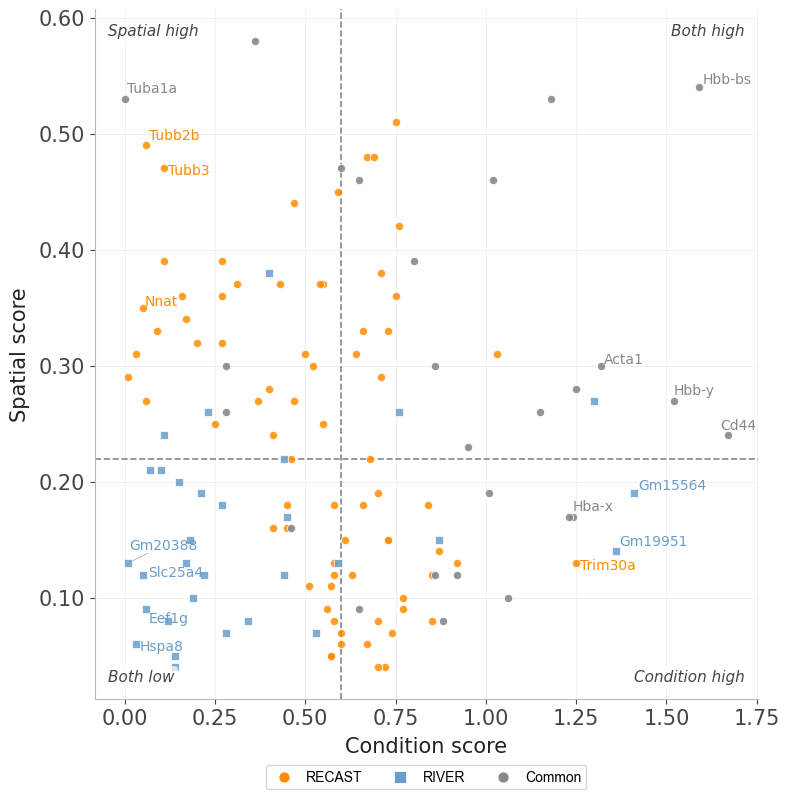

In [13]:
def plot_condition_vs_spatial_v2(
    adata_A, adata_B,
    our_genes, comp_genes,
    annotation_key="cell_name",
    top_label_n=10,
    condition_names=("E15.5", "E16.5"),
    save_path="/home_nfs/sifan.miao/1/data/DLPFC_diff/result/embroy_fig/",
    decimals=2,
):
    from matplotlib.ticker import FormatStrFormatter
    import matplotlib.lines as mlines

    condA, condB = condition_names

    df_ours = compute_gene_scores_v2(adata_A, adata_B, our_genes, annotation_key)
    df_comp = compute_gene_scores_v2(adata_A, adata_B, comp_genes, annotation_key)
    df_ours["method"] = "RECAST"
    df_comp["method"] = "RIVER"
    df_all = pd.concat([df_ours, df_comp], ignore_index=True)

    for col in ["condition_score", "spatial_score"]:
        df_all[col] = df_all[col].round(decimals)

    stat, p_spatial = mannwhitneyu(
        df_ours["spatial_score"], df_comp["spatial_score"],
        alternative="greater"
    )
    stat, p_cond = mannwhitneyu(
        df_ours["condition_score"], df_comp["condition_score"],
        alternative="two-sided"
    )
    print("p_spatial", p_spatial)
    print("p_cond", p_cond)

    PAL = {"RECAST": "#FF8C00", "RIVER": "#699ECA"}

    tick_fmt = FormatStrFormatter(f'%.{decimals}f')

    def _style_axis(ax, xlabel=None, ylabel=None):
        if xlabel:
            ax.set_xlabel(xlabel, fontsize=15, color='#222222', labelpad=6)
        if ylabel:
            ax.set_ylabel(ylabel, fontsize=15, color='#222222', labelpad=6)
        ax.xaxis.set_major_formatter(tick_fmt)
        ax.yaxis.set_major_formatter(tick_fmt)
        ax.xaxis.set_tick_params(labelsize=15, colors='#444444')
        ax.yaxis.set_tick_params(labelsize=15, colors='#444444')
        ax.grid(True, which='major', color='#EEEEEE', linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        for sp in ['left', 'bottom']:
            ax.spines[sp].set_color('#BBBBBB')
            ax.spines[sp].set_linewidth(0.8)

    from matplotlib.font_manager import FontProperties, fontManager
    _font_path = "/home_nfs/sifan.miao/anaconda3/envs/fonts/Arial.ttf"
    try:
        fontManager.addfont(_font_path)
    except (ValueError, OSError):
        pass
    _font_prop = FontProperties(fname=_font_path)

    def _style_legend(legend):
        for text in legend.get_texts():
            text.set_fontproperties(_font_prop)

    # ── 图1: 四象限图 (RECAST + RIVER) ──
    try:
        from adjustText import adjust_text
        has_adjust = True
    except ImportError:
        has_adjust = False

    df_q = df_all.copy()
    x_med = df_q["condition_score"].median()
    y_med = df_q["spatial_score"].median()
    common_genes = set(df_ours["gene"]) & set(df_comp["gene"])

    def _quadrant(row):
        cx = row["condition_score"] >= x_med
        cy = row["spatial_score"] >= y_med
        if cx and cy:   return "Q1"
        if (not cx) and cy: return "Q2"
        if (not cx) and (not cy): return "Q3"
        return "Q4"

    df_q["quadrant"] = df_q.apply(_quadrant, axis=1)

    def _pick_representative(sub, corner_x, corner_y, n=2):
        if len(sub) == 0:
            return sub
        sub = sub.copy()
        sub["dist"] = np.sqrt(
            (sub["condition_score"] - corner_x) ** 2 +
            (sub["spatial_score"] - corner_y) ** 2
        )
        return sub.nsmallest(min(n, len(sub)), "dist")

    x_min, x_max = df_q["condition_score"].min(), df_q["condition_score"].max()
    y_min, y_max = df_q["spatial_score"].min(), df_q["spatial_score"].max()
    pad_x = 0.05 * (x_max - x_min + 1e-8)
    pad_y = 0.05 * (y_max - y_min + 1e-8)

    # corner_x, corner_y 仅用于选典型基因；标签用 axes 四角坐标
    quad_specs = {
        "Q1": (x_max + pad_x, y_max + pad_y, "Both high"),
        "Q2": (x_min - pad_x, y_max + pad_y, "Spatial high"),
        "Q3": (x_min - pad_x, y_min - pad_y, "Both low"),
        "Q4": (x_max + pad_x, y_min - pad_y, "Condition high"),
    }
    # 象限标题放在四个角 (axes fraction)
    corner_text_pos = {
        "Q1": (0.98, 0.98, "right",  "top"),     # 右上
        "Q2": (0.02, 0.98, "left",   "top"),     # 左上
        "Q3": (0.02, 0.02, "left",   "bottom"),  # 左下
        "Q4": (0.98, 0.02, "right",  "bottom"),  # 右下
    }
    QUAD_COLOR = {"Q1": "#FFE8CC", "Q2": "#E8F4FD", "Q3": "#F0F0F0", "Q4": "#FDE8E8"}

    fig1, ax1 = plt.subplots(figsize=(8, 8))
    fig1.patch.set_facecolor("white")
    ax1.set_facecolor("white")

    # 象限背景
    # ax1.axvspan(x_med, x_max + pad_x * 2, ymin=0.5, ymax=1.0, color=QUAD_COLOR["Q1"], alpha=0.30, zorder=0)
    # ax1.axvspan(x_min - pad_x * 2, x_med, ymin=0.5, ymax=1.0, color=QUAD_COLOR["Q2"], alpha=0.30, zorder=0)
    # ax1.axvspan(x_min - pad_x * 2, x_med, ymin=0, ymax=0.5, color=QUAD_COLOR["Q3"], alpha=0.30, zorder=0)
    # ax1.axvspan(x_med, x_max + pad_x * 2, ymin=0, ymax=0.5, color=QUAD_COLOR["Q4"], alpha=0.30, zorder=0)

    ax1.axvline(x_med, color="#888888", ls="--", lw=1.2, zorder=1)
    ax1.axhline(y_med, color="#888888", ls="--", lw=1.2, zorder=1)

    # ── RECAST + RIVER 散点 ──
    MARKER = {"RECAST": "o", "RIVER": "s"}
    for method, grp in df_q.groupby("method"):
        common_mask = grp["gene"].isin(common_genes)
        unique_grp = grp[~common_mask]
        ax1.scatter(
            unique_grp["condition_score"], unique_grp["spatial_score"],
            s=35, alpha=0.85, color=PAL[method], marker=MARKER[method],
            edgecolors="white", linewidth=0.6, zorder=2,
        )

    if len(common_genes) > 0:
        common_pts = df_q[df_q["gene"].isin(common_genes)].drop_duplicates("gene")
        ax1.scatter(
            common_pts["condition_score"], common_pts["spatial_score"],
            s=35, alpha=0.9, color="#888888", marker="o",
            edgecolors="white", linewidth=0.6, zorder=2,
        )

    # ── 四角象限标题 ──
    for q, (_, _, label) in quad_specs.items():
        tx, ty, ha, va = corner_text_pos[q]
        ax1.text(
            tx, ty, label,
            transform=ax1.transAxes,
            fontsize=11, color="#444444", style="italic",
            ha=ha, va=va, zorder=3,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.7),
        )

    # ── 每象限标注典型基因（RECAST + RIVER 各取 n_per_method 个）──
    # texts = []
    # n_per_method = max(1, top_label_n // 8)   # 每方法每象限 1–2 个

    # for q, (cx, cy, _) in quad_specs.items():
    #     for method in ["RECAST", "RIVER"]:
    #         sub = df_q[(df_q["quadrant"] == q) & (df_q["method"] == method)]
    #         reps = _pick_representative(sub, cx, cy, n=n_per_method)
    #         for _, row in reps.iterrows():
    #             color = "#888888" if row["gene"] in common_genes else PAL[method]
    #             t = ax1.annotate(
    #                 row["gene"],
    #                 (row["condition_score"], row["spatial_score"]),
    #                 fontsize=8, color=color, zorder=4,
    #             )
    #             texts.append(t)
    texts = []
    n_per_quad = 4        # 每象限 3–5 个，可改成 3 或 5
    labeled_genes = set()   # 全局去重，防止跨象限重复（一般不需要，但更安全）

    for q, (cx, cy, _) in quad_specs.items():
        # 共同基因只保留一条，避免标两次
        sub = (
            df_q[df_q["quadrant"] == q]
            .drop_duplicates("gene", keep="first")
        )
        reps = _pick_representative(sub, cx, cy, n=n_per_quad)

        for _, row in reps.iterrows():
            if row["gene"] in labeled_genes:
                continue
            labeled_genes.add(row["gene"])

            if row["gene"] in common_genes:
                color = "#888888"
            else:
                color = PAL[row["method"]]

            t = ax1.annotate(
                row["gene"],
                (row["condition_score"], row["spatial_score"]),
                fontsize=10, color=color, zorder=4,
            )
            texts.append(t)
    if has_adjust and texts:
        adjust_text(texts, ax=ax1, arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.6))

    _style_axis(ax1, xlabel="Condition score", ylabel="Spatial score")

    # 图例
    handles = []
    for method in ["RECAST", "RIVER"]:
        handles.append(mlines.Line2D(
            [], [], color=PAL[method], linewidth=0, marker=MARKER[method],
            markersize=8, markerfacecolor=PAL[method],
            markeredgecolor="white", markeredgewidth=0.6, label=method,
        ))
    if len(common_genes) > 0:
        handles.append(mlines.Line2D(
            [], [], color="#888888", linewidth=0, marker="o",
            markersize=8, markerfacecolor="#888888",
            markeredgecolor="white", markeredgewidth=0.6, label="Common",
        ))
    legend = ax1.legend(handles=handles, loc="lower center",
                        bbox_to_anchor=(0.5, -0.14), ncol=3,
                        frameon=True, facecolor="white", edgecolor="#CCCCCC", fontsize=9)
    _style_legend(legend)

    plt.tight_layout()
    if save_path:
        plt.savefig(f"{save_path.rstrip('/')}_quadrant.png", dpi=300,
                    bbox_inches="tight", facecolor="white")
    plt.show()

    return df_all


df_result = plot_condition_vs_spatial_v2(
    adata_A    = ad0_raw,
    adata_B    = ad1_raw,
    our_genes  = result["gene"].values[:100],
    comp_genes = river_ranks[:100],
    annotation_key  = "annotation",
    condition_names = ("E12.5", "E14.5"),
    top_label_n     = 16,   # 四象限 × 两方法，约 8–16 个基因名
)


In [26]:
def plot_condition_vs_spatial_v3(
    adata_A, adata_B,
    our_genes, comp_genes, deg_genes,
    annotation_key="cell_name",
    top_label_n=10,
    condition_names=("E15.5", "E16.5"),
    save_path="/home_nfs/sifan.miao/1/data/DLPFC_diff/result/embroy_fig/",
    decimals=2,
    deg_method_name="DEG(Wilcoxon)",
):
    from matplotlib.ticker import FormatStrFormatter
    import matplotlib.lines as mlines
    from collections import Counter

    condA, condB = condition_names

    df_ours = compute_gene_scores_v2(adata_A, adata_B, our_genes, annotation_key)
    df_comp = compute_gene_scores_v2(adata_A, adata_B, comp_genes, annotation_key)
    df_deg  = compute_gene_scores_v2(adata_A, adata_B, deg_genes,  annotation_key)

    df_ours["method"] = "RECAST"
    df_comp["method"] = "RIVER"
    df_deg["method"]  = deg_method_name
    df_all = pd.concat([df_ours, df_comp, df_deg], ignore_index=True)

    for col in ["condition_score", "spatial_score"]:
        df_all[col] = df_all[col].round(decimals)

    # 可选：打印统计检验
    stat, p_spatial = mannwhitneyu(
        df_ours["spatial_score"], df_comp["spatial_score"], alternative="greater"
    )
    stat, p_cond = mannwhitneyu(
        df_ours["condition_score"], df_comp["condition_score"], alternative="two-sided"
    )
    print("p_spatial (RECAST vs RIVER)", p_spatial)
    print("p_cond (RECAST vs RIVER)", p_cond)

    PAL = {
        "RECAST": "#FF8C00",
        "RIVER": "#699ECA",
        deg_method_name: "#F898CB",
    }
    MARKER = {
        "RECAST": "o",
        "RIVER": "s",
        deg_method_name: "^",
    }
    METHOD_ORDER = ["RECAST", "RIVER", deg_method_name]

    tick_fmt = FormatStrFormatter(f'%.{decimals}f')

    def _style_axis(ax, xlabel=None, ylabel=None):
        if xlabel:
            ax.set_xlabel(xlabel, fontsize=15, color='#222222', labelpad=6)
        if ylabel:
            ax.set_ylabel(ylabel, fontsize=15, color='#222222', labelpad=6)
        ax.xaxis.set_major_formatter(tick_fmt)
        ax.yaxis.set_major_formatter(tick_fmt)
        ax.xaxis.set_tick_params(labelsize=15, colors='#444444')
        ax.yaxis.set_tick_params(labelsize=15, colors='#444444')
        ax.grid(True, which='major', color='#EEEEEE', linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        for sp in ['left', 'bottom']:
            ax.spines[sp].set_color('#BBBBBB')
            ax.spines[sp].set_linewidth(0.8)

    from matplotlib.font_manager import FontProperties, fontManager
    _font_path = "/home_nfs/sifan.miao/anaconda3/envs/fonts/Arial.ttf"
    try:
        fontManager.addfont(_font_path)
    except (ValueError, OSError):
        pass
    _font_prop = FontProperties(fname=_font_path)

    def _style_legend(legend):
        for text in legend.get_texts():
            text.set_fontproperties(_font_prop)

    try:
        from adjustText import adjust_text
        has_adjust = True
    except ImportError:
        has_adjust = False

    df_q = df_all.copy()
    x_med = df_q["condition_score"].median()
    y_med = df_q["spatial_score"].median()

    # 出现在 ≥2 个方法中的基因 → 灰色
    gene_counts = Counter()
    for df_m in [df_ours, df_comp, df_deg]:
        gene_counts.update(set(df_m["gene"]))
    common_genes = {g for g, c in gene_counts.items() if c >= 2}

    def _quadrant(row):
        cx = row["condition_score"] >= x_med
        cy = row["spatial_score"] >= y_med
        if cx and cy:              return "Q1"
        if (not cx) and cy:        return "Q2"
        if (not cx) and (not cy):  return "Q3"
        return "Q4"

    df_q["quadrant"] = df_q.apply(_quadrant, axis=1)

    def _pick_representative(sub, corner_x, corner_y, n=2):
        if len(sub) == 0:
            return sub
        sub = sub.copy()
        sub["dist"] = np.sqrt(
            (sub["condition_score"] - corner_x) ** 2 +
            (sub["spatial_score"] - corner_y) ** 2
        )
        return sub.nsmallest(min(n, len(sub)), "dist")

    x_min, x_max = df_q["condition_score"].min(), df_q["condition_score"].max()
    y_min, y_max = df_q["spatial_score"].min(), df_q["spatial_score"].max()
    pad_x = 0.05 * (x_max - x_min + 1e-8)
    pad_y = 0.05 * (y_max - y_min + 1e-8)

    quad_specs = {
        "Q1": (x_max + pad_x, y_max + pad_y, "Both high"),
        "Q2": (x_min - pad_x, y_max + pad_y, "Spatial high"),
        "Q3": (x_min - pad_x, y_min - pad_y, "Both low"),
        "Q4": (x_max + pad_x, y_min - pad_y, "Condition high"),
    }
    corner_text_pos = {
        "Q1": (0.98, 0.98, "right",  "top"),
        "Q2": (0.02, 0.98, "left",   "top"),
        "Q3": (0.02, 0.02, "left",   "bottom"),
        "Q4": (0.98, 0.02, "right",  "bottom"),
    }

    fig1, ax1 = plt.subplots(figsize=(8, 8))
    fig1.patch.set_facecolor("white")
    ax1.set_facecolor("white")

    ax1.axvline(x_med, color="#888888", ls="--", lw=1.2, zorder=1)
    ax1.axhline(y_med, color="#888888", ls="--", lw=1.2, zorder=1)

    # 三组散点
    for method in METHOD_ORDER:
        grp = df_q[df_q["method"] == method]
        unique_grp = grp[~grp["gene"].isin(common_genes)]
        ax1.scatter(
            unique_grp["condition_score"], unique_grp["spatial_score"],
            s=35, alpha=0.85, color=PAL[method], marker=MARKER[method],
            edgecolors="white", linewidth=0.6, zorder=2,
        )

    if len(common_genes) > 0:
        common_pts = df_q[df_q["gene"].isin(common_genes)].drop_duplicates("gene")
        ax1.scatter(
            common_pts["condition_score"], common_pts["spatial_score"],
            s=35, alpha=0.9, color="#888888", marker="o",
            edgecolors="white", linewidth=0.6, zorder=2,
        )

    for q, (_, _, label) in quad_specs.items():
        tx, ty, ha, va = corner_text_pos[q]
        ax1.text(
            tx, ty, label,
            transform=ax1.transAxes,
            fontsize=11, color="#444444", style="italic",
            ha=ha, va=va, zorder=3,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="none", alpha=0.7),
        )

    texts = []
    n_per_quad = 4
    labeled_genes = set()

    for q, (cx, cy, _) in quad_specs.items():
        sub = (
            df_q[df_q["quadrant"] == q]
            .drop_duplicates("gene", keep="first")
        )
        reps = _pick_representative(sub, cx, cy, n=n_per_quad)

        for _, row in reps.iterrows():
            if row["gene"] in labeled_genes:
                continue
            labeled_genes.add(row["gene"])
            color = "#888888" if row["gene"] in common_genes else PAL[row["method"]]
            t = ax1.annotate(
                row["gene"],
                (row["condition_score"], row["spatial_score"]),
                fontsize=10, color=color, zorder=4,
            )
            texts.append(t)

    if has_adjust and texts:
        adjust_text(texts, ax=ax1, arrowprops=dict(arrowstyle="-", color="#AAAAAA", lw=0.6))

    _style_axis(ax1, xlabel="Condition score", ylabel="Spatial score")

    handles = []
    for method in METHOD_ORDER:
        handles.append(mlines.Line2D(
            [], [], color=PAL[method], linewidth=0, marker=MARKER[method],
            markersize=8, markerfacecolor=PAL[method],
            markeredgecolor="white", markeredgewidth=0.6, label=method,
        ))
    if len(common_genes) > 0:
        handles.append(mlines.Line2D(
            [], [], color="#888888", linewidth=0, marker="o",
            markersize=8, markerfacecolor="#888888",
            markeredgecolor="white", markeredgewidth=0.6, label="Common",
        ))

    legend = ax1.legend(
        handles=handles, loc="lower center",
        bbox_to_anchor=(0.5, -0.14), ncol=4,
        frameon=True, facecolor="white", edgecolor="#CCCCCC", fontsize=9,
    )
    _style_legend(legend)

    plt.tight_layout()
    if save_path:
        plt.savefig(
            f"{save_path.rstrip('/')}_quadrant_v3.png", dpi=300,
            bbox_inches="tight", facecolor="white",
        )
    plt.show()

    return df_all

p_spatial (RECAST vs RIVER) 0.03524540454059599
p_cond (RECAST vs RIVER) 0.45978920349707764


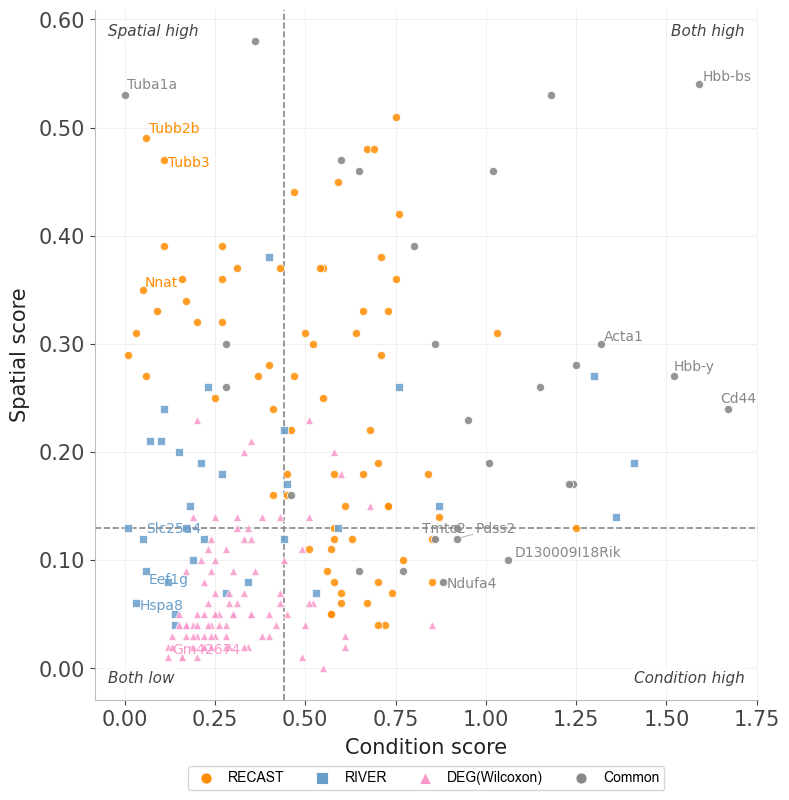

In [31]:
df_result = plot_condition_vs_spatial_v3(
    adata_A    = ad0_raw,
    adata_B    = ad1_raw,
    our_genes  = result["gene"].values[:100],
    comp_genes = river_ranks[:100],
    deg_genes= deg_df['names'][:100].tolist(),
    annotation_key  = "annotation",
    condition_names = ("E12.5", "E14.5"),
    top_label_n     = 16,   # 四象限 × 两方法，约 8–16 个基因名
)


In [14]:
import pandas as pd
def compute_svg_genes(adata_A, adata_B, top_n=2000):
    morans_A = adata_A.uns["moranI"]["I"].sort_values(ascending=False)
    morans_B = adata_B.uns["moranI"]["I"].sort_values(ascending=False)
    svg_A = set(morans_A.head(top_n).index)
    svg_B = set(morans_B.head(top_n).index)
    svg_all = svg_A | svg_B
    s_a = morans_A.reindex(svg_all)
    s_b = morans_B.reindex(svg_all)
    avg_I = pd.concat([s_a, s_b], axis=1).mean(axis=1, skipna=True)
    return avg_I.sort_values(ascending=False).index.tolist()
svg_all=compute_svg_genes(ad_ref, ad_qry, top_n=2000)

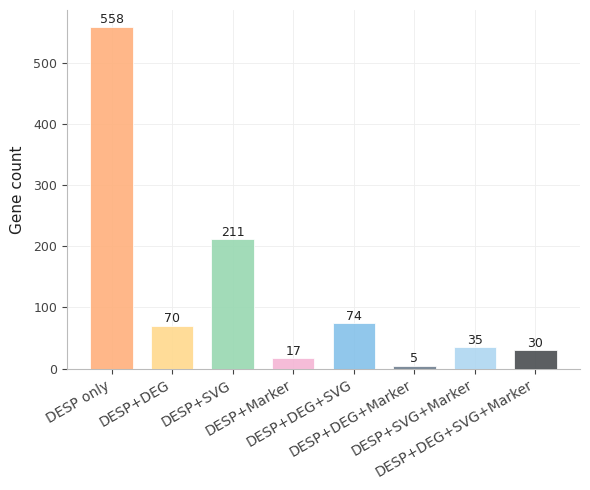

In [32]:
marker_gene = pd.read_csv("/home_nfs/sifan.miao/1/data/marker_gen_embryo.csv", encoding='gbk')
marker_gene_clean = marker_gene[marker_gene['Symbol'].notna()]
marker_gene_list=marker_gene_clean['Symbol'].tolist()
desp_genes =set(result['gene'][:1000].tolist())
deg_genes=set(deg_df["names"][:1000].tolist())
svg_genes= set(list(svg_all)[:1000])
marker_genes = set(marker_gene_clean['Symbol'].tolist())
df_score = result
vibrant_colors = [
        "#FF8C00",  # DESP only (鲜艳绿)
        "#FFCB5B",  # +DEG (黄)
        "#E87B1E",  # +SVG (橙)
        "#0076B9",  # +Marker (蓝)
        "#FFB347",  # +DEG+SVG (深灰)
        "#699ECA",  # 备用蓝
        "#F898CB",  # 备用粉
        "#333333",  # All four
    ]

    # --- 2. 计算交集 ---
D, E, S, M = desp_genes, deg_genes, svg_genes, marker_genes
intersections = {
        "DESP only":           D - E - S - M,
        "DESP+DEG":            (D & E) - S - M,
        "DESP+SVG":            (D & S) - E - M,
        "DESP+Marker":         (D & M) - E - S,
        "DESP+DEG+SVG":        (D & E & S) - M,
        "DESP+DEG+Marker":     (D & E & M) - S,
        "DESP+SVG+Marker":     (D & S & M) - E,
        "DESP+DEG+SVG+Marker": (D & E & S & M),
    }

counts = [len(intersections[k]) for k in intersections.keys()]
# 全称标签，用于横坐标
full_labels = list(intersections.keys())

# --- 3. 准备 Top 基因数据 ---
score_map = df_score.set_index("gene")["score"].to_dict()
key_inters = ["DESP+DEG", "DESP+SVG"]
top_gene_data = {}
for k in key_inters:
    genes = intersections[k]
    scored = [(g, score_map.get(g, 0)) for g in genes]
    scored.sort(key=lambda x: x[1], reverse=True)
    top_gene_data[k] = scored[:15]

# fig1, ax1 = plt.subplots(figsize=(6, 5), facecolor="white")
# vibrant_colors = ["#FF8C00","#FFCB5B","#4DAF4A","#F898CB", "#0076B9", "#3D505A", "#699ECA",  "#1A1A1A"]
# 柔和莫兰蒂色系：灰橙、灰黄、灰绿、灰粉、深蓝灰、冷灰蓝、浅蓝灰、深炭灰
# 清爽低饱和：粉橙、淡金、薄荷绿、淡粉、天蓝、烟灰蓝、淡青、炭黑
vibrant_colors = [
    "#FFB07C",  # 柔和橙 (DESP only - 核心突出)
    "#FFD98D",  # 奶油黄
    "#98D8B1",  # 薄荷绿
    "#F4B5D4",  # 樱花粉
    "#85C1E9",  # 晴空蓝
    "#708090",  # 灰蓝色 (用于中性重叠)
    "#AED6F1",  # 淡水蓝
    "#4A4E51"   # 深灰 (All four)
]

# bars = ax1.bar(full_labels, counts, color=vibrant_colors, 
#                edgecolor="white", linewidth=0.6, alpha=0.9, width=0.7)

# ax1.spines[['top', 'right']].set_visible(False)
# ax1.set_ylabel("Gene count")
# ax1.set_xticks(range(len(full_labels)))
# ax1.set_xticklabels(full_labels, rotation=30, ha="right")

# # 数值标注
# for bar in bars:
#     height = bar.get_height()
#     if height > 0:
#         ax1.text(bar.get_x() + bar.get_width()/2, height + 1, str(int(height)), 
#                  ha='center', va='bottom', fontsize=9)

# plt.tight_layout()
# plt.savefig("plot_1_bar.png", bbox_inches="tight",dpi=1200)
# plt.show()
fig1, ax1 = plt.subplots(figsize=(6, 5))
fig1.patch.set_facecolor("white")
ax1.set_facecolor("white")

bars = ax1.bar(
    full_labels, counts,
    color=vibrant_colors,
    edgecolor="white", linewidth=0.6, alpha=0.9, width=0.7,
    zorder=3
)

# ---------- 坐标轴风格：对齐 compare_multiple_gene_lists ----------
ax1.set_ylabel("Gene count", fontsize=11, color="#222222", labelpad=6)

ax1.set_xticks(range(len(full_labels)))
ax1.set_xticklabels(full_labels, rotation=30, ha="right", fontsize=10, color="#222222")

ax1.yaxis.set_tick_params(labelsize=9, colors="#444444")
ax1.xaxis.set_tick_params(colors="#444444")

# 网格线（灰色、在柱子下面）
ax1.yaxis.grid(True, color="#EEEEEE", linewidth=0.6, zorder=0)
ax1.set_axisbelow(True)

# 竖直分割线（和之前折线图一致的“列分割”观感）
for x in range(len(full_labels)):
    ax1.axvline(x=x, color="#EEEEEE", linewidth=0.6, linestyle="-", zorder=0)

# 边框设置
for sp in ["top", "right"]:
    ax1.spines[sp].set_visible(False)
for sp in ["left", "bottom"]:
    ax1.spines[sp].set_color("#BBBBBB")
    ax1.spines[sp].set_linewidth(0.8)

# 数值标注
for bar in bars:
    height = bar.get_height()
    if height > 0:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            str(int(height)),
            ha="center", va="bottom",
            fontsize=9, color="#222222"
        )

plt.tight_layout()
plt.savefig("plot_1_bar.png", bbox_inches="tight", dpi=1200, facecolor="white")
plt.show()

查询 GO Biological Process ...
  GO: 112 个显著 term
查询 KEGG ...
  KEGG: 45 个显著 term

绘图中 ...


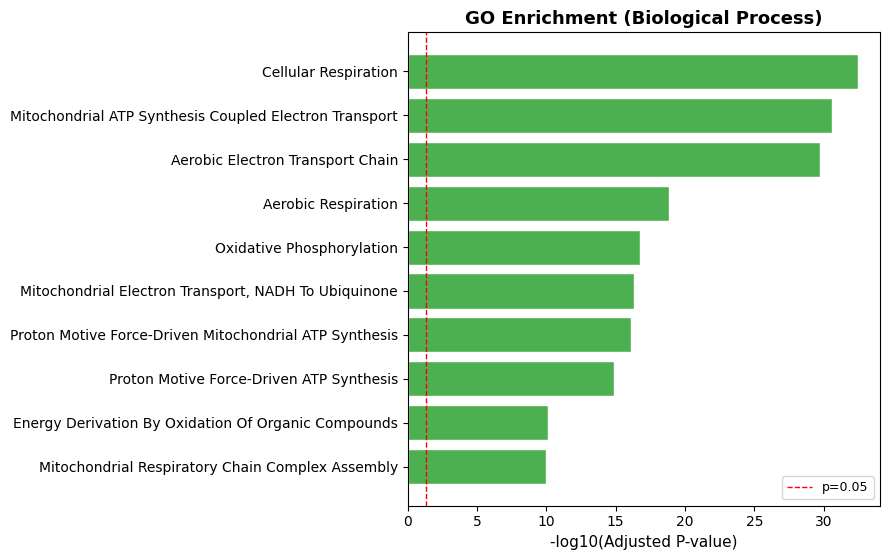

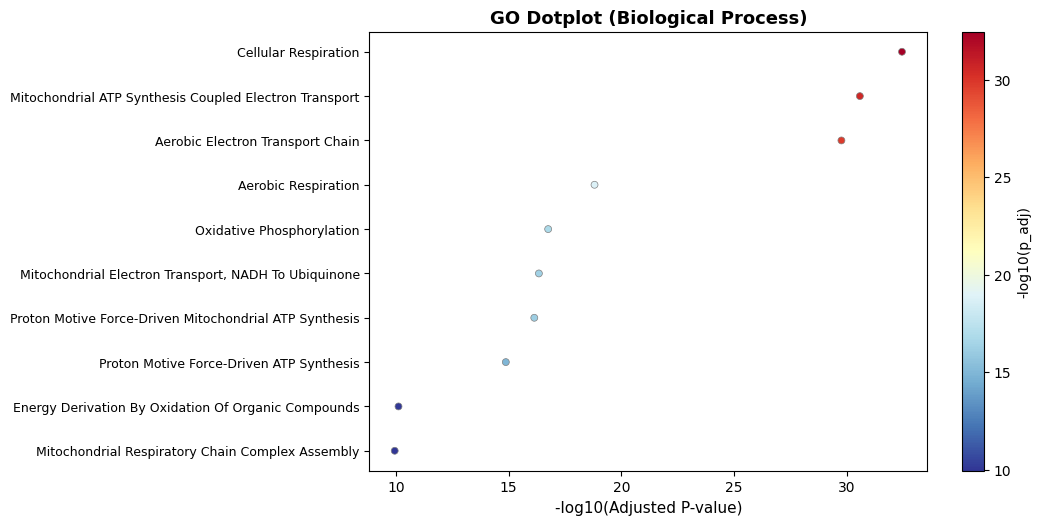

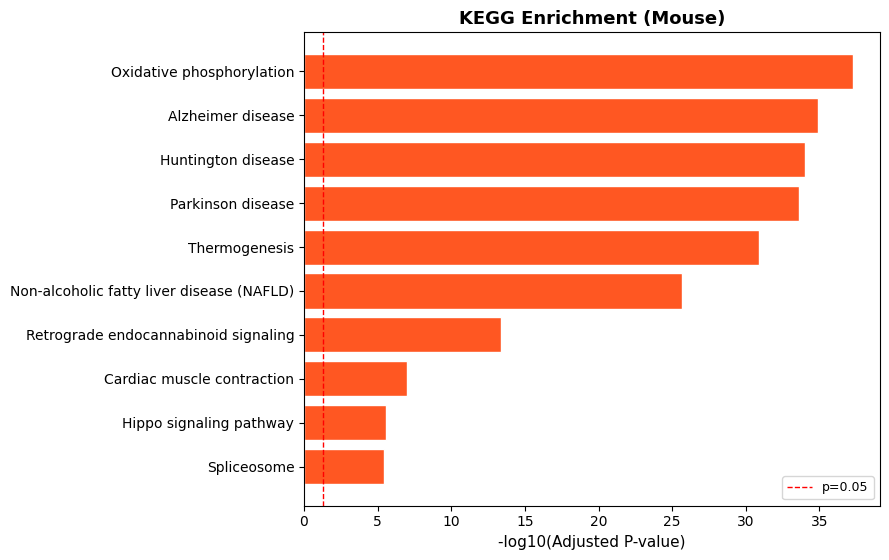

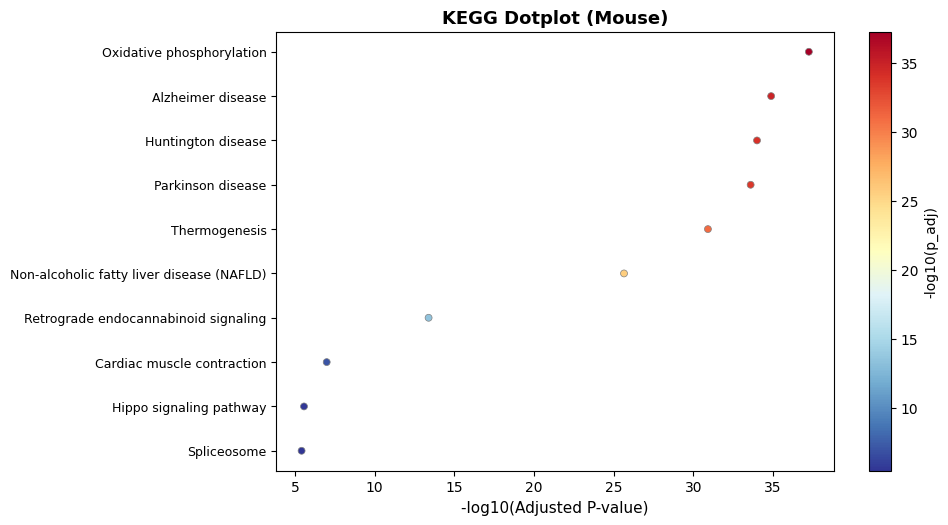

In [33]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
# genes=list(gene_set_analy['dsep_unique'])
# genes= [gene for gene in genes if not gene.startswith('Gm')]

genes= intersections["DESP only"]
genes= [gene for gene in genes if not gene.startswith('Gm')]
# genes=list(result_4['gene'][:200])
BASE = "https://maayanlab.cloud/Enrichr"

def enrichr_query(gene_list, gene_set):
    r = requests.post(f"{BASE}/addList",
                      files={"list": (None, "\n".join(gene_list)),
                             "description": (None, "query")})
    r.raise_for_status()
    user_id = r.json()["userListId"]
    time.sleep(0.5)

    r2 = requests.get(f"{BASE}/enrich",
                      params={"userListId": user_id, "backgroundType": gene_set})
    r2.raise_for_status()
    data = r2.json().get(gene_set, [])

    cols = ["Rank", "Term", "P-value", "Z-score", "Combined score",
            "Genes", "Adjusted P-value", "Old P-value", "Old Adjusted P-value"]
    return pd.DataFrame(data, columns=cols)

# ── 3. 运行富集 ───────────────────────────────────────────────
print("查询 GO Biological Process ...")
go_df = enrichr_query(genes, "GO_Biological_Process_2023")
go_df = go_df[go_df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
print(f"  GO: {len(go_df)} 个显著 term")

print("查询 KEGG ...")
kegg_df = enrichr_query(genes, "KEGG_2019_Mouse")
kegg_df = kegg_df[kegg_df["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
# kegg_df.to_csv("kegg_results.csv", index=False)
print(f"  KEGG: {len(kegg_df)} 个显著 term")

# ── 4. 可视化 ─────────────────────────────────────────────────
def barplot(df, title,  color, top_n=10):
    if df.empty:
        print(f"  跳过 {title}（无显著结果）"); return
    d = df.head(top_n).copy()
    d["label"] = d["Term"].str.replace(r"\(GO:\d+\)", "", regex=True).str.strip().str[:55]
    d["-logP"] = -d["Adjusted P-value"].apply(lambda p: math.log10(p + 1e-300))
    fig, ax = plt.subplots(figsize=(9, top_n * 0.42 + 1.5))
    ax.barh(d["label"][::-1], d["-logP"][::-1], color=color, edgecolor="white")
    ax.axvline(-math.log10(0.05), color="red", ls="--", lw=1, label="p=0.05")
    ax.set_xlabel("-log10(Adjusted P-value)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=9); plt.tight_layout()
    plt.savefig("/home_nfs/sifan.miao/1/result/fig/MOSTA/Go.png", dpi=1200); 
    plt.show()

def dotplot(df, title,  top_n=10):
    if df.empty:
        print(f"  跳过 {title}（无显著结果）"); return
    d = df.head(top_n).copy()
    d["label"] = d["Term"].str.replace(r"\(GO:\d+\)", "", regex=True).str.strip().str[:55]
    d["-logP"] = -d["Adjusted P-value"].apply(lambda p: math.log10(p + 1e-300))
    d["GeneCount"] = d["Genes"].apply(lambda x: len(str(x).split(";")))
    fig, ax = plt.subplots(figsize=(9, top_n * 0.42 + 1.5))
    sc = ax.scatter(d["-logP"][::-1], range(top_n),
                    s=d["GeneCount"][::-1] * 25,
                    c=d["-logP"][::-1], cmap="RdYlBu_r",
                    edgecolors="grey", linewidth=0.5)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(d["label"].values[::-1], fontsize=9)
    ax.set_xlabel("-log10(Adjusted P-value)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.colorbar(sc, ax=ax, label="-log10(p_adj)")
    # plt.tight_layout(); plt.savefig(outfile, dpi=150); plt.close()
    # print(f"  保存: {outfile}")

print("\n绘图中 ...")
barplot(go_df,   "GO Enrichment (Biological Process)",    "#4CAF50")
dotplot(go_df,   "GO Dotplot (Biological Process)",  )
barplot(kegg_df, "KEGG Enrichment (Mouse)",    "#FF5722")
dotplot(kegg_df, "KEGG Dotplot (Mouse)" )